<a href="https://colab.research.google.com/github/Felinchen76/experimental_gans/blob/main/experimental_gans_cifar_100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN auf Cifar-100 mit Einschränkung auf 5 ausgewählte Subklassen

### Einleitung: Generative Adversarial Networks (GANs)

Generative Adversarial Networks (GANs), eingeführt von Ian Goodfellow im Jahr 2014, sind ein Ansatz im Bereich des unüberwachten Lernens zur Generierung realistischer Daten. Ein GAN besteht aus zwei gegeneinander trainierten neuronalen Netzen – dem **Generator** und dem **Diskriminator (je nachdem auch Critic)**:

* Der **Generator** versucht, synthetische Daten (im Folgenden Bilder) zu erzeugen, die möglichst realistisch wirken.
* Der **Diskriminator** versucht zu erkennen, ob ein gegebenes Bild echt (aus den Trainingsdaten) oder vom Generator erzeugt ist.

Beide Netze verbessern sich gegenseitig in einem **adversarialen Spiel**: Der Generator wird darin geschult, den Diskriminator zu täuschen, während der Diskriminator lernt, zwischen echt und künstlich zu unterscheiden. Durch diesen Wettbewerb lernen GANs, realistisch wirkende Daten zu erzeugen, ohne, dass die Definition von expliziten Zielwerten erforderlich ist.

Eine Erweiterung dieses Konzepts ist das **Conditional GAN (cGAN)**. Hierbei werden beide Netzwerke zusätzlich mit einem **Label** (z. B. hier "Apfel" oder "Lampe") konditioniert, sodass der Generator gezielt Bilder zu einer bestimmten Klasse erzeugen kann. Dies ist besonders nützlich, wenn kontrollierte Generierung gewünscht ist. Dies kann beispielsweise der Fall sein, bei synthetischer Datenerweiterung in Klassifikationsaufgaben oder für das Ermöglichen einer gezielten Simulation.

# **Vergleich der implementierten Modellansätze**

| **Modell**                 | **Architektur-Typ**                                | **Wichtige Komponenten**                                                                       | **Loss-Funktion**              | **Trainingstricks**                                                   | **Besonderheiten**                            |
| -------------------------- | -------------------------------------------------- | ---------------------------------------------------------------------------------------------- | ------------------------------ | --------------------------------------------------------------------- | --------------------------------------------- |
| **1. cGAN Basic**          | Conditional GAN (klassisch)                        | - Label Embedding<br>- Conv-basierter Generator & Discriminator                                | Binary Cross-Entropy (BCE)     | - One-Hot Embedding<br>- Feste Noise-Vektoren                         | Einstieg in bedingte GANs                     |
| **2. BigGAN-artig**        | Advanced cGAN (BigGAN-ähnlich)                     | - Conditional BatchNorm<br>- Residual Blocks<br>- Self-Attention<br>- Projection Discriminator | Hinge Loss                     | - Spectral Norm<br>- Layer-Normalisierung<br>- Fixe Architekturblöcke | Nah an echten BigGAN-Strukturen          |
| **3. WGAN-GP (ResNet)**    | Wasserstein GAN mit Gradient Penalty               | - Labelmaps als Zusatzkanäle<br>- ResNet-Blocks<br>- Critic statt Discriminator                | Wasserstein + Gradient Penalty | - FID-Score<br>- Training des Critics mehrfach pro Schritt            | Stabileres Training, realistischerer Score    |
| **4. WGAN-GP mit MaxNorm** | Wie (3), aber mit stärkerem Regularisierungstuning | - Max-Norm Clipping<br>- Learning Rate Schedulers<br>- Fixes Noise für Evaluation              | Wasserstein + Gradient Penalty | - Gradient Clipping (max\_norm)<br>- Lernratenabfall                  | Durchdachtes Training, bessere Kontrolle |


### Importe der benötigten Klassen

In [ ]:
import os
import pickle
import numpy as np
import tensorflow as tf
import pandas as pd

from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import time

from tensorflow.keras.layers import SpectralNormalization
from tensorflow.keras import mixed_precision

from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from torchvision.models import inception_v3, Inception_V3_Weights


from scipy.linalg import sqrtm

import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_

import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import datasets, transforms, models
from torchvision.transforms.functional import resize

import torch.autograd as autograd
from torchvision.datasets import CIFAR100

In [ ]:
def plot_training_progress(loss_C, loss_G, fid_list=None, lr=None):
    epochs = range(1, len(loss_C) + 1)

    fig, ax1 = plt.subplots(figsize=(10,5))

    ax1.plot(epochs, loss_C, 'r-', label='Critic Loss')
    ax1.plot(epochs, loss_G, 'b-', label='Generator Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    if fid_list is not None and len(fid_list) > 0:
        ax2 = ax1.twinx()
        fid_epochs = epochs[-len(fid_list):]
        ax2.plot(fid_epochs, fid_list, 'g--', label='FID')
        ax2.set_ylabel('FID')
        ax2.legend(loc='upper right')

    plt.title(f"Training Progress bei lr={lr}")
    plt.show()


In [ ]:
def save_generated_images(generator, latent_dim, classes, device, epoch, save_dir="./generated_images", n_per_class=1):
    generator.eval()
    os.makedirs(save_dir, exist_ok=True)

    with torch.no_grad():
        all_imgs = []
        for class_idx, cls_name in enumerate(classes):
            z = torch.randn(n_per_class, latent_dim, device=device)
            labels = torch.full((n_per_class,), class_idx, dtype=torch.long, device=device)
            imgs = generator(z, labels).cpu()
            all_imgs.append((cls_name, imgs))

        # Bilder speichern
        for cls_name, imgs in all_imgs:
            for i, img in enumerate(imgs):
                img = img * 0.5 + 0.5  # [-1,1] zu [0,1]
                img_np = img.permute(1, 2, 0).numpy()
                fname = f"epoch{epoch}_{cls_name}_{i}.png"
                fpath = os.path.join(save_dir, fname)
                plt.imsave(fpath, img_np)



# **Training eines Conditional GANs auf ausgewählten CIFAR-100-Subklassen**

### **Übersicht**

In diesem Projekt wurde ein Conditional Generative Adversarial Network (cGAN) auf einer Teilmenge des CIFAR-100-Datensatzes trainiert. Ziel war es, realistisch wirkende Bilder für fünf ausgewählte Objektklassen zu generieren. Die verwendeten Klassen sind:

```
'apple', 'bottle', 'bowl', 'keyboard', 'lamp'
```

### **1. Motivation & Zielsetzung**

Generative Adversarial Networks (GANs) sind ein leistungsstarkes Mittel zur Bilderzeugung. Ein *conditional* GAN erweitert die Standard-GAN-Architektur, indem es die Generierung von Bildern gezielt an Klassenlabels knüpft. So kann gezielt kontrolliert werden, welche Art von Bild generiert wird (z. B. eine „Lampe“ statt eines „Apfels“).

---

### **2. Datensatzvorverarbeitung**

Der vollständige CIFAR-100-Datensatz wurde geladen, aber anschließend auf nur 5 Klassen gefiltert. Die Bilder wurden normalisiert (Pixelwerte in $-1, 1$) und mithilfe eines benutzerdefinierten `FilteredDataset`-Wrappers wurden die Labels passend zu einem neu definierten Mapping (`class_to_idx`) auf die Indizes 0 bis 4 umcodiert.

```python
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
```

---

### **3. Architektur**

#### **Generator**

Der Generator nimmt als Eingabe:

* einen Zufallsvektor (Noise) `z ∈ ℝ^100`
* ein Klassenlabel (Embedding mit One-Hot-Struktur)

Diese werden zusammengeführt und durch ein lineares Layer und anschließend mehrere Upsampling- und Convolution-Blöcke geleitet, um ein RGB-Bild der Größe 32×32 zu erzeugen. Die finale Aktivierung ist `Tanh()`.

```python
self.label_emb = nn.Embedding(n_classes, n_classes)  # One-hot ähnlich
```

#### **Discriminator**

Der Diskriminator erhält sowohl ein Bild als auch ein Klassenlabel. Das Label wird wie ein zusätzlicher Bildkanal verarbeitet: Das One-Hot-Embedding wird über das Bild repliziert und dann mit dem Bild konkateniert (entlang der Kanalachse). Die Architektur besteht aus mehreren Conv-Layern mit LeakyReLU und BatchNorm, gefolgt von einer linearen Entscheidungsschicht mit Sigmoid.

---

### **4. Trainingsdetails**

* Optimierer: Adam (LR = 0.0002, β₁ = 0.5, β₂ = 0.999)
* Verlustfunktion: Binary Cross Entropy (`BCELoss`)
* Batchgröße: 64
* Epochen: 300
* Fixed Noise für Visualisierung: 5 feste Noise-Vektoren + zugehörige Labels

```python
loss_D = loss_real + loss_fake
loss_G = criterion(output_gen, labels_real)
```

#### **Trainingsschritte pro Batch:**

1. **Discriminator**

   * Trainiert auf echten Bildern (`label=1`)
   * Trainiert auf generierten Bildern (`label=0`)

2. **Generator**

   * Trainiert darauf, den Diskriminator zu täuschen (`label=1` für Fake-Bilder)

---

### **5. Evaluation & Visualisierung**

Alle 10 Epochen werden Beispielbilder für jede Klasse generiert und visuell dargestellt. Dafür wird das Netz auf einen festen Satz an `noise` und `labels` angewendet. Die Darstellung erfolgt mit matplotlib.

```python
fig, axs = plt.subplots(1, len(selected_classes), figsize=(15, 3))
```

Zusätzlich werden Generator- und Diskriminatorverluste über die Epochen geplottet, um das Training zu evaluieren.

---

### **6. Ergebnisse & Beobachtungen**

* Einige Klassen (z. B. Apfel oder Flasche) wurden deutlich besser generiert als andere (z. B. Tastatur), was auf unterschiedliche Komplexität und Varianz im Originaldatensatz zurückzuführen ist.
* Die Lernkurven zeigen konvergierendes Verhalten, allerdings mit typischen Schwankungen bei GANs.
* Die Labels als Embedding zu verwenden, ermöglichte eine gezielte und kontrollierte Generierung pro Klasse.

---

### **7. Mögliche Erweiterungen**

* Verwendung eines *One-Hot-Vektor-Embeddings* statt dimensionsgleicher Label-Vektoren.
* Anwendung auf mehr Klassen oder auch CIFAR-10 zum Vergleich.
* Einsatz eines ResNet-basierten Diskriminators für stabileres Training.
* Wechsel zur Wasserstein-Lossfunktion (WGAN) für konstantere Gradienten.

---

### **8. Fazit**

Das implementierte Conditional GAN zeigt eine solide Ausgangssituation für die Generierung synthetischer Bilddaten auf einer CIFAR-100-Teilmenge. Die Umsetzung verdeutlicht die Funktionalität und das Zusammenspiel von Generator und Diskriminator mit bedingten Eingaben. Durch geeignete Erweiterungen lässt sich die Qualität weiter steigern.


Epoch [1/300] Loss_D: 1.2130 Loss_G: 1.0225
Epoch [2/300] Loss_D: 1.6571 Loss_G: 0.8904
Epoch [3/300] Loss_D: 1.2721 Loss_G: 1.4555
Epoch [4/300] Loss_D: 1.4549 Loss_G: 1.0087
Epoch [5/300] Loss_D: 1.4217 Loss_G: 0.9874
Epoch [6/300] Loss_D: 1.6481 Loss_G: 1.2518
Epoch [7/300] Loss_D: 1.5532 Loss_G: 0.5518
Epoch [8/300] Loss_D: 1.6613 Loss_G: 1.0589
Epoch [9/300] Loss_D: 1.4450 Loss_G: 0.4615
Epoch [10/300] Loss_D: 0.8593 Loss_G: 1.5886


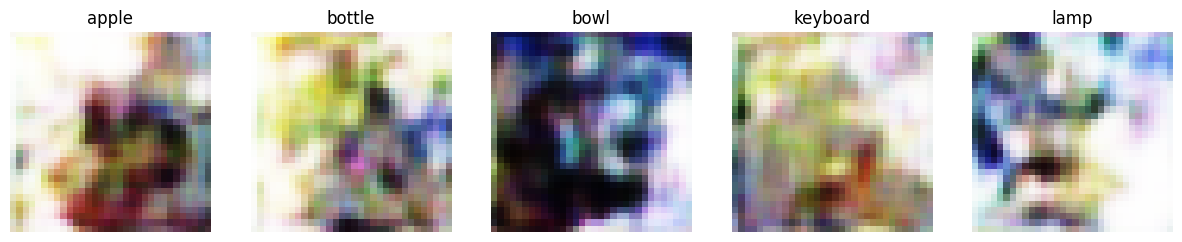

Epoch [11/300] Loss_D: 1.6291 Loss_G: 1.2400
Epoch [12/300] Loss_D: 1.3348 Loss_G: 1.0666
Epoch [13/300] Loss_D: 1.2496 Loss_G: 1.8398
Epoch [14/300] Loss_D: 1.5666 Loss_G: 1.4299
Epoch [15/300] Loss_D: 1.0565 Loss_G: 1.0458
Epoch [16/300] Loss_D: 1.3226 Loss_G: 1.7394
Epoch [17/300] Loss_D: 1.7095 Loss_G: 1.5781
Epoch [18/300] Loss_D: 1.1133 Loss_G: 1.4674
Epoch [19/300] Loss_D: 1.0005 Loss_G: 1.2883
Epoch [20/300] Loss_D: 1.4916 Loss_G: 0.6882


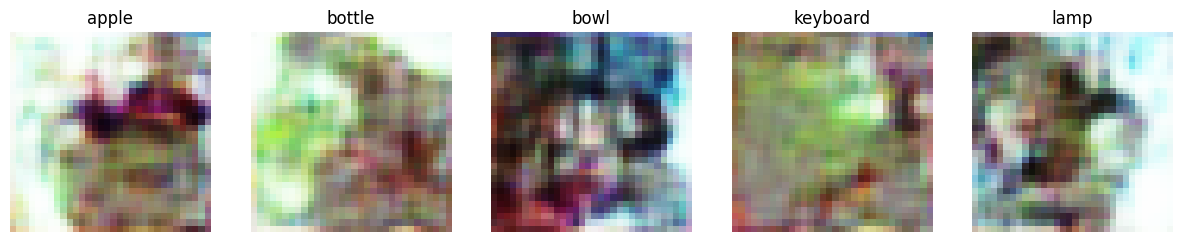

Epoch [21/300] Loss_D: 1.4450 Loss_G: 1.2533
Epoch [22/300] Loss_D: 1.2157 Loss_G: 1.3387
Epoch [23/300] Loss_D: 1.1532 Loss_G: 2.0400
Epoch [24/300] Loss_D: 1.2427 Loss_G: 1.2256
Epoch [25/300] Loss_D: 1.4204 Loss_G: 1.1871
Epoch [26/300] Loss_D: 1.1453 Loss_G: 1.8814
Epoch [27/300] Loss_D: 1.3653 Loss_G: 0.9602
Epoch [28/300] Loss_D: 1.5933 Loss_G: 1.5870
Epoch [29/300] Loss_D: 1.7276 Loss_G: 1.3358
Epoch [30/300] Loss_D: 1.9362 Loss_G: 0.5134


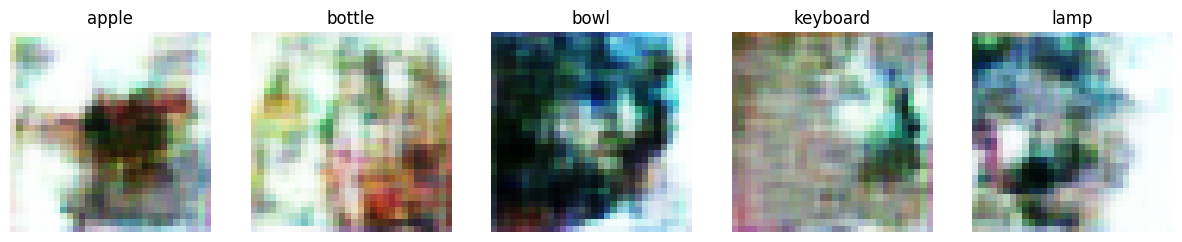

Epoch [31/300] Loss_D: 1.8383 Loss_G: 0.9843
Epoch [32/300] Loss_D: 1.4068 Loss_G: 0.8099
Epoch [33/300] Loss_D: 1.2800 Loss_G: 1.4530
Epoch [34/300] Loss_D: 1.0931 Loss_G: 1.4023
Epoch [35/300] Loss_D: 1.4452 Loss_G: 0.8552
Epoch [36/300] Loss_D: 1.5091 Loss_G: 2.3582
Epoch [37/300] Loss_D: 1.3380 Loss_G: 0.9692
Epoch [38/300] Loss_D: 1.1851 Loss_G: 1.6297
Epoch [39/300] Loss_D: 1.4308 Loss_G: 1.4212
Epoch [40/300] Loss_D: 1.8184 Loss_G: 1.0894


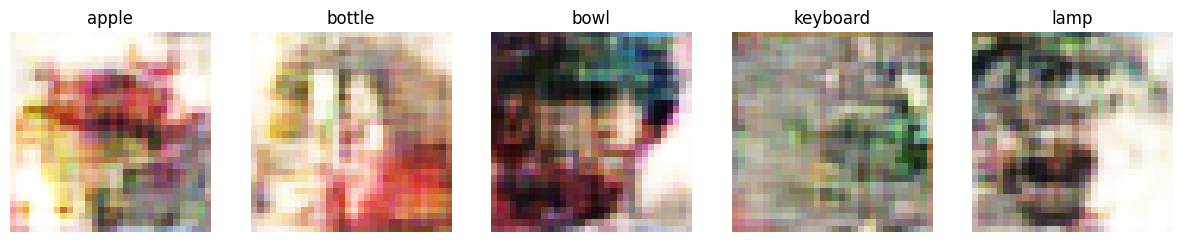

Epoch [41/300] Loss_D: 1.5119 Loss_G: 0.8543
Epoch [42/300] Loss_D: 1.4289 Loss_G: 1.2477
Epoch [43/300] Loss_D: 1.1798 Loss_G: 1.6087
Epoch [44/300] Loss_D: 1.4943 Loss_G: 1.2313
Epoch [45/300] Loss_D: 1.2123 Loss_G: 1.3460
Epoch [46/300] Loss_D: 1.2885 Loss_G: 0.9882
Epoch [47/300] Loss_D: 1.3874 Loss_G: 0.9327
Epoch [48/300] Loss_D: 1.2375 Loss_G: 1.3774
Epoch [49/300] Loss_D: 1.4261 Loss_G: 1.1577
Epoch [50/300] Loss_D: 1.1469 Loss_G: 1.3416


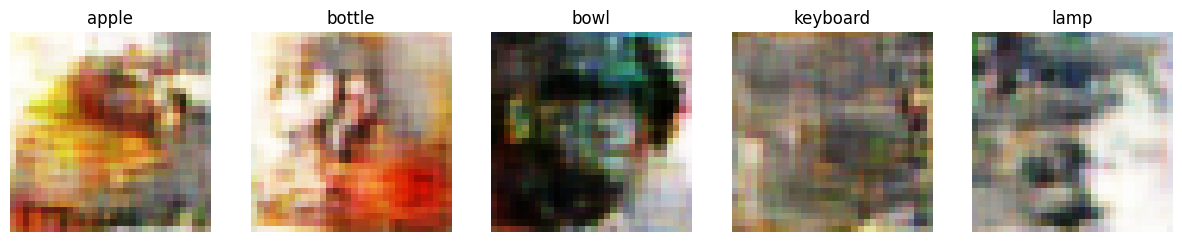

Epoch [51/300] Loss_D: 1.3755 Loss_G: 1.2403
Epoch [52/300] Loss_D: 1.4441 Loss_G: 0.8737
Epoch [53/300] Loss_D: 1.5316 Loss_G: 0.7670
Epoch [54/300] Loss_D: 1.2590 Loss_G: 1.2932
Epoch [55/300] Loss_D: 1.0977 Loss_G: 1.7270
Epoch [56/300] Loss_D: 1.4882 Loss_G: 1.4117
Epoch [57/300] Loss_D: 1.3592 Loss_G: 0.9169
Epoch [58/300] Loss_D: 1.8652 Loss_G: 1.3810
Epoch [59/300] Loss_D: 1.6015 Loss_G: 1.0141
Epoch [60/300] Loss_D: 1.5932 Loss_G: 0.7853


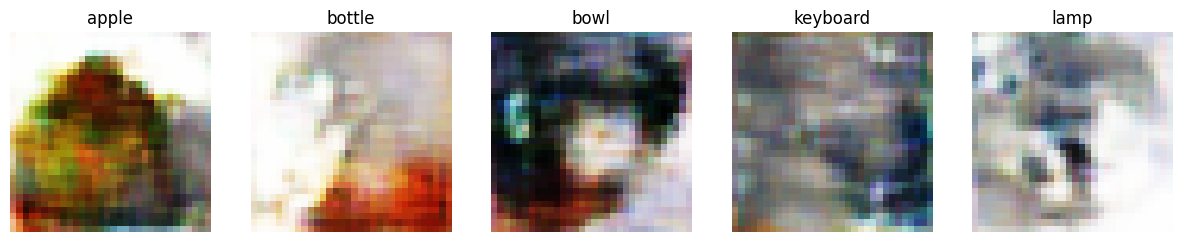

Epoch [61/300] Loss_D: 1.6855 Loss_G: 0.9286
Epoch [62/300] Loss_D: 1.3355 Loss_G: 1.2148
Epoch [63/300] Loss_D: 1.1420 Loss_G: 1.4355
Epoch [64/300] Loss_D: 1.2644 Loss_G: 1.2317
Epoch [65/300] Loss_D: 1.1110 Loss_G: 1.7986
Epoch [66/300] Loss_D: 1.6449 Loss_G: 1.2373
Epoch [67/300] Loss_D: 1.3746 Loss_G: 1.0769
Epoch [68/300] Loss_D: 1.4253 Loss_G: 1.1295
Epoch [69/300] Loss_D: 1.3589 Loss_G: 1.0932
Epoch [70/300] Loss_D: 1.2103 Loss_G: 1.7792


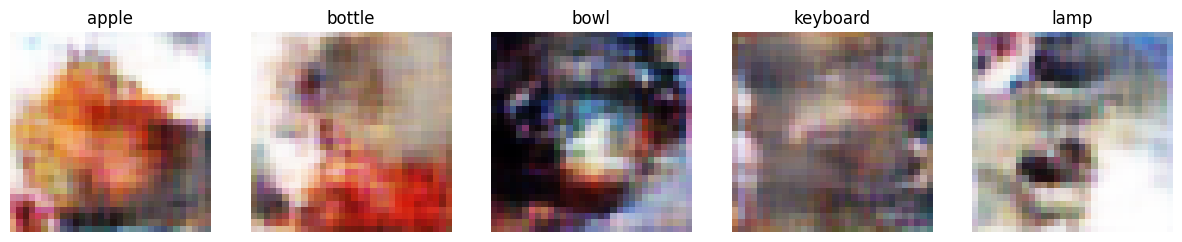

Epoch [71/300] Loss_D: 1.2298 Loss_G: 1.0601
Epoch [72/300] Loss_D: 1.5278 Loss_G: 1.0723
Epoch [73/300] Loss_D: 1.4331 Loss_G: 0.9108
Epoch [74/300] Loss_D: 1.3781 Loss_G: 1.2968
Epoch [75/300] Loss_D: 1.5049 Loss_G: 1.3901
Epoch [76/300] Loss_D: 1.4179 Loss_G: 0.9941
Epoch [77/300] Loss_D: 1.5390 Loss_G: 0.9556
Epoch [78/300] Loss_D: 1.6327 Loss_G: 1.2130
Epoch [79/300] Loss_D: 1.3790 Loss_G: 1.1116
Epoch [80/300] Loss_D: 1.2648 Loss_G: 1.7025


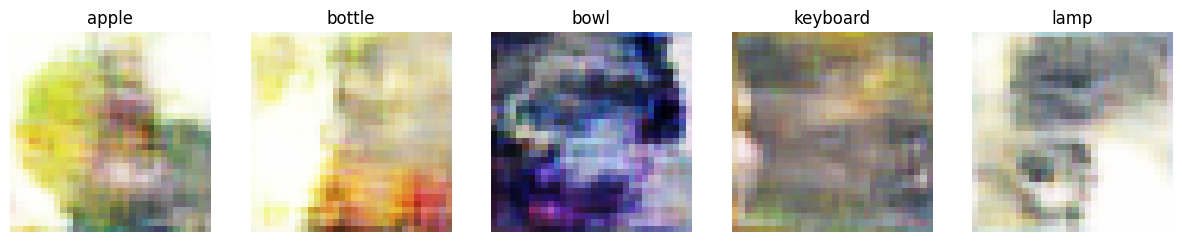

Epoch [81/300] Loss_D: 1.5965 Loss_G: 1.4361
Epoch [82/300] Loss_D: 1.5449 Loss_G: 0.5576
Epoch [83/300] Loss_D: 1.2267 Loss_G: 1.1146
Epoch [84/300] Loss_D: 0.9892 Loss_G: 1.2963
Epoch [85/300] Loss_D: 1.5631 Loss_G: 1.0257
Epoch [86/300] Loss_D: 1.2896 Loss_G: 1.6268
Epoch [87/300] Loss_D: 1.3642 Loss_G: 0.7941
Epoch [88/300] Loss_D: 1.2651 Loss_G: 1.3663
Epoch [89/300] Loss_D: 1.6155 Loss_G: 0.5903
Epoch [90/300] Loss_D: 1.5985 Loss_G: 1.2289


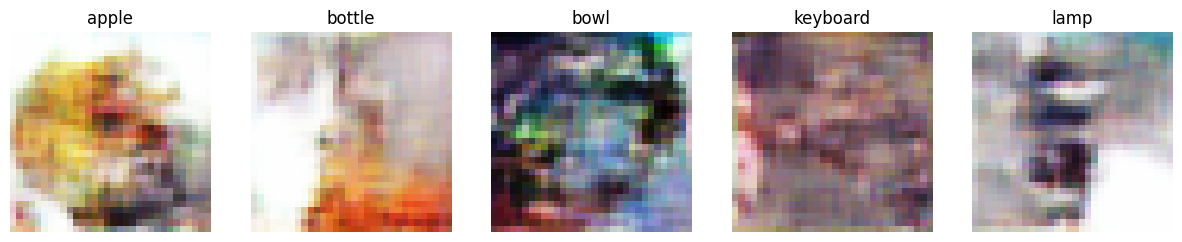

Epoch [91/300] Loss_D: 1.2136 Loss_G: 2.0001
Epoch [92/300] Loss_D: 1.0058 Loss_G: 1.5735
Epoch [93/300] Loss_D: 1.4763 Loss_G: 1.3577
Epoch [94/300] Loss_D: 1.5302 Loss_G: 1.2300
Epoch [95/300] Loss_D: 1.4178 Loss_G: 0.8913
Epoch [96/300] Loss_D: 1.3755 Loss_G: 0.9473
Epoch [97/300] Loss_D: 1.6487 Loss_G: 1.1895
Epoch [98/300] Loss_D: 1.1102 Loss_G: 1.3219
Epoch [99/300] Loss_D: 1.4237 Loss_G: 1.0235
Epoch [100/300] Loss_D: 1.4543 Loss_G: 1.1004


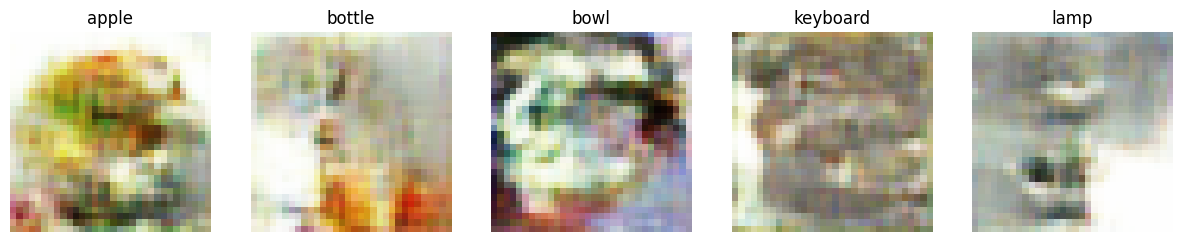

Epoch [101/300] Loss_D: 1.6470 Loss_G: 1.0491
Epoch [102/300] Loss_D: 1.1234 Loss_G: 1.6843
Epoch [103/300] Loss_D: 1.2891 Loss_G: 1.7774
Epoch [104/300] Loss_D: 1.3179 Loss_G: 1.4183
Epoch [105/300] Loss_D: 1.5833 Loss_G: 1.4338
Epoch [106/300] Loss_D: 1.3877 Loss_G: 1.3104
Epoch [107/300] Loss_D: 1.4386 Loss_G: 1.4280
Epoch [108/300] Loss_D: 1.7949 Loss_G: 1.0740
Epoch [109/300] Loss_D: 1.0673 Loss_G: 1.2297
Epoch [110/300] Loss_D: 1.2076 Loss_G: 1.3251


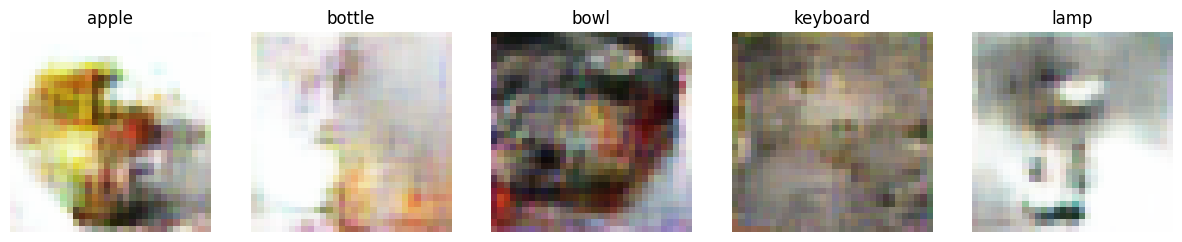

Epoch [111/300] Loss_D: 1.4547 Loss_G: 1.0570
Epoch [112/300] Loss_D: 1.2899 Loss_G: 1.1907
Epoch [113/300] Loss_D: 1.1970 Loss_G: 1.0311
Epoch [114/300] Loss_D: 1.5289 Loss_G: 1.0647
Epoch [115/300] Loss_D: 1.2081 Loss_G: 1.3266
Epoch [116/300] Loss_D: 1.6239 Loss_G: 1.1535
Epoch [117/300] Loss_D: 1.4933 Loss_G: 1.4765
Epoch [118/300] Loss_D: 1.3418 Loss_G: 1.5312
Epoch [119/300] Loss_D: 1.2730 Loss_G: 1.5943
Epoch [120/300] Loss_D: 1.0271 Loss_G: 2.3606


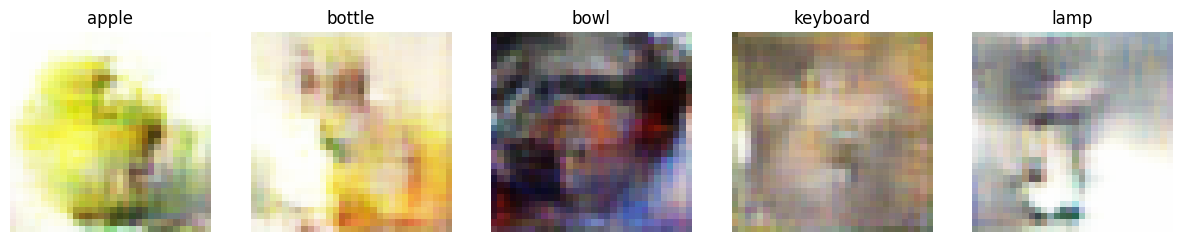

Epoch [121/300] Loss_D: 1.4967 Loss_G: 1.2208
Epoch [122/300] Loss_D: 1.2802 Loss_G: 1.8404
Epoch [123/300] Loss_D: 2.0776 Loss_G: 1.2272
Epoch [124/300] Loss_D: 1.6175 Loss_G: 1.4024
Epoch [125/300] Loss_D: 1.3349 Loss_G: 1.4454
Epoch [126/300] Loss_D: 1.5456 Loss_G: 1.0391
Epoch [127/300] Loss_D: 1.3428 Loss_G: 1.1873
Epoch [128/300] Loss_D: 1.5576 Loss_G: 1.5697
Epoch [129/300] Loss_D: 1.2911 Loss_G: 1.7936
Epoch [130/300] Loss_D: 1.2788 Loss_G: 1.6686


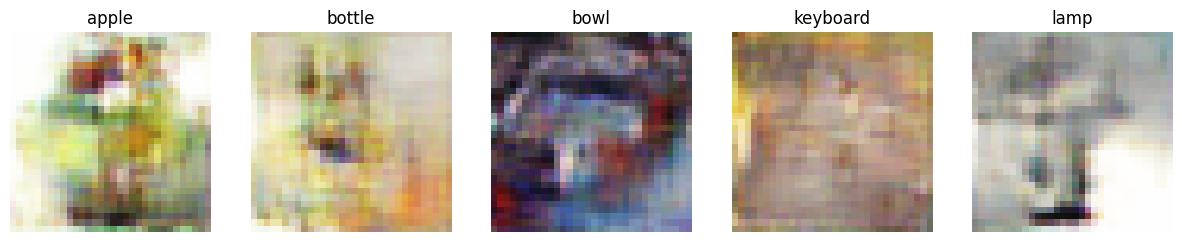

Epoch [131/300] Loss_D: 1.0889 Loss_G: 1.1743
Epoch [132/300] Loss_D: 1.0513 Loss_G: 1.0758
Epoch [133/300] Loss_D: 1.0792 Loss_G: 1.3770
Epoch [134/300] Loss_D: 1.3867 Loss_G: 1.1866
Epoch [135/300] Loss_D: 1.2572 Loss_G: 1.3520
Epoch [136/300] Loss_D: 1.0209 Loss_G: 1.7212
Epoch [137/300] Loss_D: 1.4899 Loss_G: 1.1539
Epoch [138/300] Loss_D: 1.1296 Loss_G: 1.5740
Epoch [139/300] Loss_D: 1.9626 Loss_G: 0.7581
Epoch [140/300] Loss_D: 1.2980 Loss_G: 1.5000


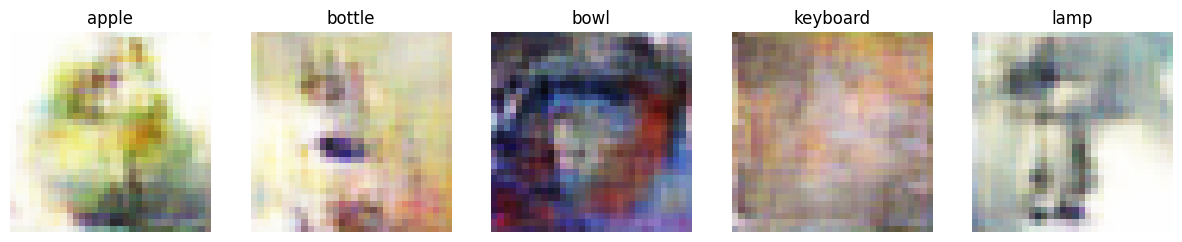

Epoch [141/300] Loss_D: 1.1603 Loss_G: 1.4180
Epoch [142/300] Loss_D: 1.6207 Loss_G: 0.8892
Epoch [143/300] Loss_D: 1.3835 Loss_G: 1.2221
Epoch [144/300] Loss_D: 1.6890 Loss_G: 1.8044
Epoch [145/300] Loss_D: 1.3169 Loss_G: 1.6497
Epoch [146/300] Loss_D: 1.5800 Loss_G: 1.0401
Epoch [147/300] Loss_D: 1.3721 Loss_G: 1.4801
Epoch [148/300] Loss_D: 1.4650 Loss_G: 1.0388
Epoch [149/300] Loss_D: 1.2522 Loss_G: 1.4928
Epoch [150/300] Loss_D: 1.2019 Loss_G: 1.0520


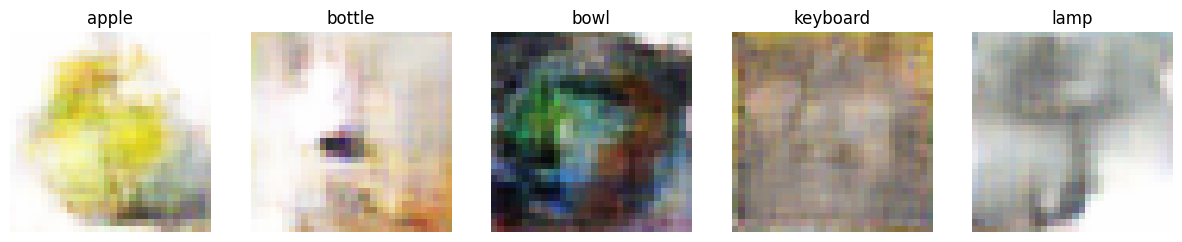

Epoch [151/300] Loss_D: 1.2180 Loss_G: 1.4635
Epoch [152/300] Loss_D: 1.1092 Loss_G: 1.8048
Epoch [153/300] Loss_D: 1.3561 Loss_G: 1.8885
Epoch [154/300] Loss_D: 1.1900 Loss_G: 1.3460
Epoch [155/300] Loss_D: 1.4538 Loss_G: 1.0179
Epoch [156/300] Loss_D: 0.9579 Loss_G: 2.4192
Epoch [157/300] Loss_D: 1.6096 Loss_G: 0.6495
Epoch [158/300] Loss_D: 1.1812 Loss_G: 1.2323
Epoch [159/300] Loss_D: 1.4379 Loss_G: 1.6776
Epoch [160/300] Loss_D: 1.5597 Loss_G: 1.2125


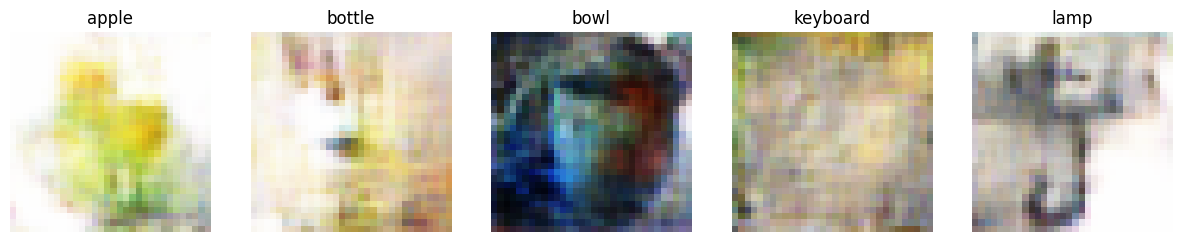

Epoch [161/300] Loss_D: 1.4893 Loss_G: 1.1826
Epoch [162/300] Loss_D: 1.4268 Loss_G: 1.3147
Epoch [163/300] Loss_D: 1.3682 Loss_G: 1.2857
Epoch [164/300] Loss_D: 1.3342 Loss_G: 1.3234
Epoch [165/300] Loss_D: 1.2692 Loss_G: 0.8336
Epoch [166/300] Loss_D: 1.1644 Loss_G: 1.5121
Epoch [167/300] Loss_D: 1.3473 Loss_G: 1.4571
Epoch [168/300] Loss_D: 1.0833 Loss_G: 1.3987
Epoch [169/300] Loss_D: 1.2553 Loss_G: 1.7111
Epoch [170/300] Loss_D: 1.2481 Loss_G: 1.4147


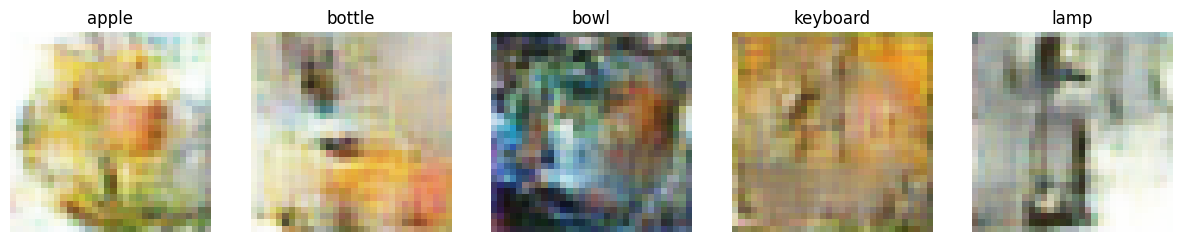

Epoch [171/300] Loss_D: 1.1167 Loss_G: 1.5214
Epoch [172/300] Loss_D: 1.5374 Loss_G: 1.2656
Epoch [173/300] Loss_D: 1.4532 Loss_G: 0.8627
Epoch [174/300] Loss_D: 1.2585 Loss_G: 1.5860
Epoch [175/300] Loss_D: 1.4040 Loss_G: 1.3385
Epoch [176/300] Loss_D: 1.1190 Loss_G: 1.4245
Epoch [177/300] Loss_D: 0.9966 Loss_G: 1.2347
Epoch [178/300] Loss_D: 0.9443 Loss_G: 1.8305
Epoch [179/300] Loss_D: 1.2469 Loss_G: 0.9553
Epoch [180/300] Loss_D: 0.9683 Loss_G: 1.9525


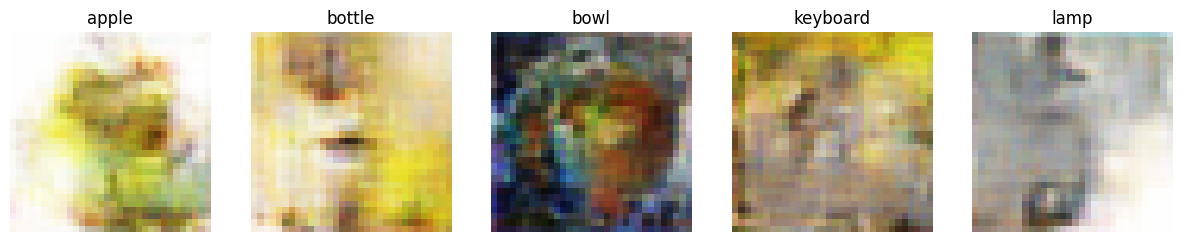

Epoch [181/300] Loss_D: 1.1649 Loss_G: 1.6076
Epoch [182/300] Loss_D: 1.3971 Loss_G: 1.3632
Epoch [183/300] Loss_D: 1.4021 Loss_G: 1.2385
Epoch [184/300] Loss_D: 1.8584 Loss_G: 0.7176
Epoch [185/300] Loss_D: 0.9997 Loss_G: 1.6141
Epoch [186/300] Loss_D: 1.4372 Loss_G: 0.7285
Epoch [187/300] Loss_D: 1.6384 Loss_G: 0.9892
Epoch [188/300] Loss_D: 1.2998 Loss_G: 1.0860
Epoch [189/300] Loss_D: 1.0313 Loss_G: 1.6223
Epoch [190/300] Loss_D: 0.8697 Loss_G: 1.6415


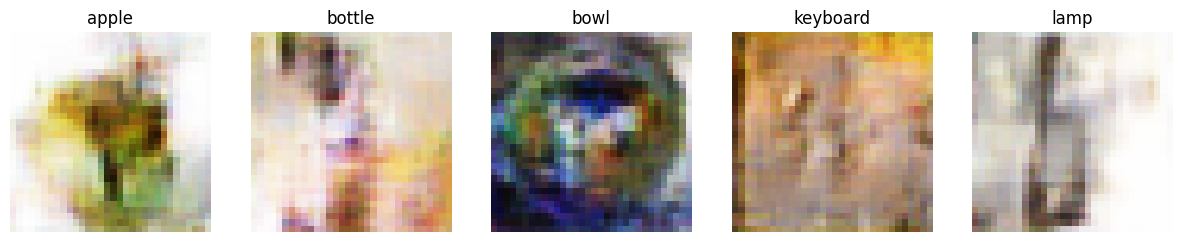

Epoch [191/300] Loss_D: 1.1239 Loss_G: 1.2378
Epoch [192/300] Loss_D: 1.5269 Loss_G: 1.8186
Epoch [193/300] Loss_D: 1.3364 Loss_G: 1.3882
Epoch [194/300] Loss_D: 1.6769 Loss_G: 1.1373
Epoch [195/300] Loss_D: 1.5111 Loss_G: 1.0328
Epoch [196/300] Loss_D: 1.1468 Loss_G: 1.0100
Epoch [197/300] Loss_D: 1.3091 Loss_G: 1.6190
Epoch [198/300] Loss_D: 1.1302 Loss_G: 0.7839
Epoch [199/300] Loss_D: 1.4264 Loss_G: 0.8505
Epoch [200/300] Loss_D: 1.1598 Loss_G: 2.0709


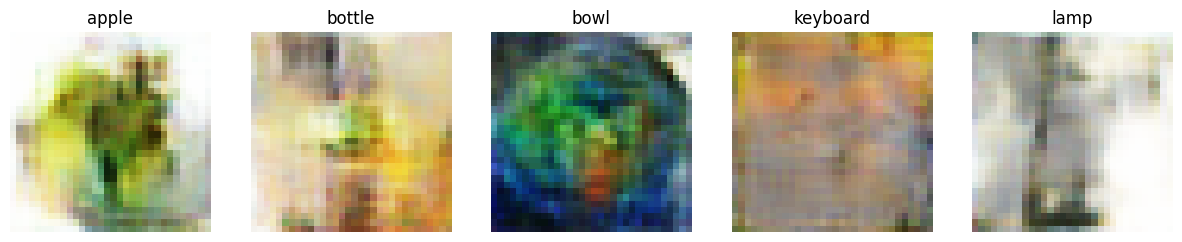

Epoch [201/300] Loss_D: 1.1628 Loss_G: 1.8701
Epoch [202/300] Loss_D: 1.4286 Loss_G: 1.6555
Epoch [203/300] Loss_D: 1.3574 Loss_G: 1.0686
Epoch [204/300] Loss_D: 1.4352 Loss_G: 1.0666
Epoch [205/300] Loss_D: 1.2411 Loss_G: 1.1090
Epoch [206/300] Loss_D: 1.2596 Loss_G: 0.8837
Epoch [207/300] Loss_D: 0.9640 Loss_G: 1.9627
Epoch [208/300] Loss_D: 1.4399 Loss_G: 1.4439
Epoch [209/300] Loss_D: 1.3068 Loss_G: 1.5205
Epoch [210/300] Loss_D: 1.4672 Loss_G: 1.9137


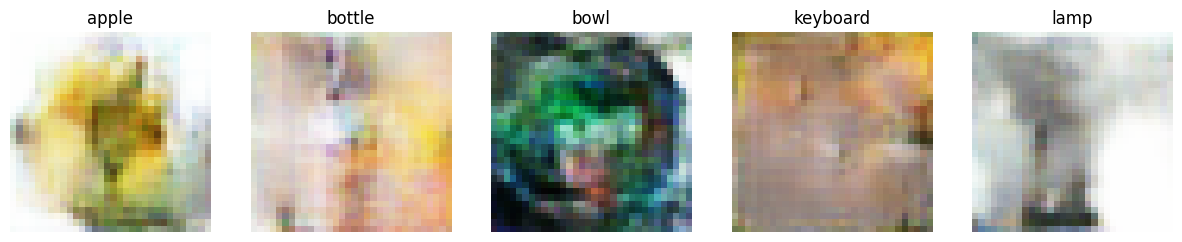

Epoch [211/300] Loss_D: 1.3521 Loss_G: 1.5244
Epoch [212/300] Loss_D: 1.1703 Loss_G: 2.5156
Epoch [213/300] Loss_D: 1.0895 Loss_G: 1.5770
Epoch [214/300] Loss_D: 0.8166 Loss_G: 1.2947
Epoch [215/300] Loss_D: 1.5078 Loss_G: 1.5099
Epoch [216/300] Loss_D: 1.4378 Loss_G: 1.5904
Epoch [217/300] Loss_D: 1.5269 Loss_G: 0.9216
Epoch [218/300] Loss_D: 1.4824 Loss_G: 1.8762
Epoch [219/300] Loss_D: 1.2727 Loss_G: 2.8444
Epoch [220/300] Loss_D: 1.0506 Loss_G: 2.0756


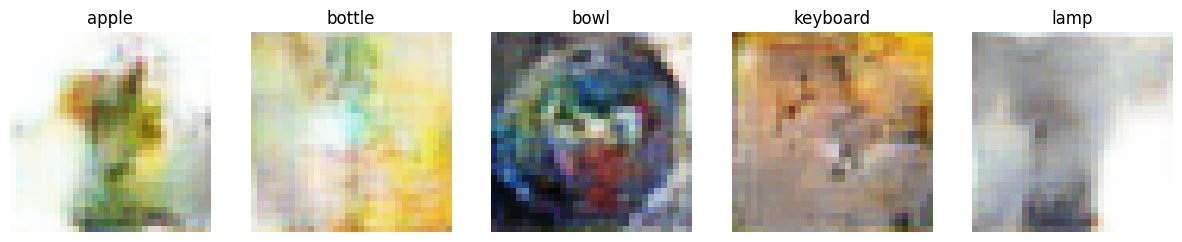

Epoch [221/300] Loss_D: 0.9863 Loss_G: 1.4436
Epoch [222/300] Loss_D: 1.2871 Loss_G: 1.3162
Epoch [223/300] Loss_D: 1.0219 Loss_G: 2.0132
Epoch [224/300] Loss_D: 0.8976 Loss_G: 2.3633
Epoch [225/300] Loss_D: 1.5680 Loss_G: 1.9126
Epoch [226/300] Loss_D: 1.6300 Loss_G: 1.1725
Epoch [227/300] Loss_D: 1.0132 Loss_G: 1.7795
Epoch [228/300] Loss_D: 1.3785 Loss_G: 1.9187
Epoch [229/300] Loss_D: 1.2466 Loss_G: 1.2786
Epoch [230/300] Loss_D: 1.2676 Loss_G: 1.1099


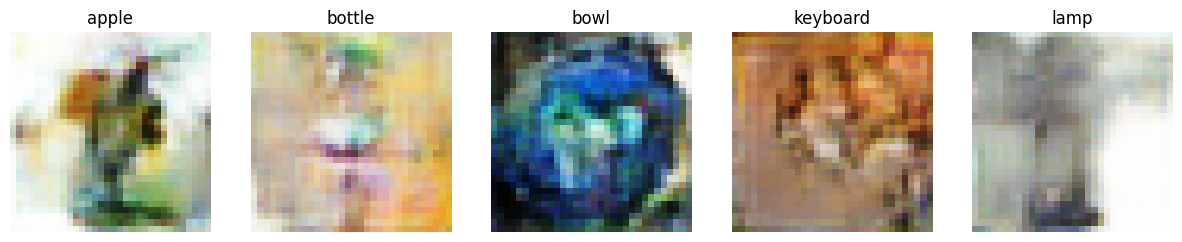

Epoch [231/300] Loss_D: 1.2508 Loss_G: 2.3936
Epoch [232/300] Loss_D: 1.3306 Loss_G: 2.7123
Epoch [233/300] Loss_D: 1.1484 Loss_G: 1.5212
Epoch [234/300] Loss_D: 1.2169 Loss_G: 1.4964
Epoch [235/300] Loss_D: 0.9437 Loss_G: 2.2091
Epoch [236/300] Loss_D: 1.3104 Loss_G: 1.5692
Epoch [237/300] Loss_D: 1.2757 Loss_G: 1.8380
Epoch [238/300] Loss_D: 1.0756 Loss_G: 1.7765
Epoch [239/300] Loss_D: 1.0798 Loss_G: 2.0438
Epoch [240/300] Loss_D: 1.0510 Loss_G: 1.1569


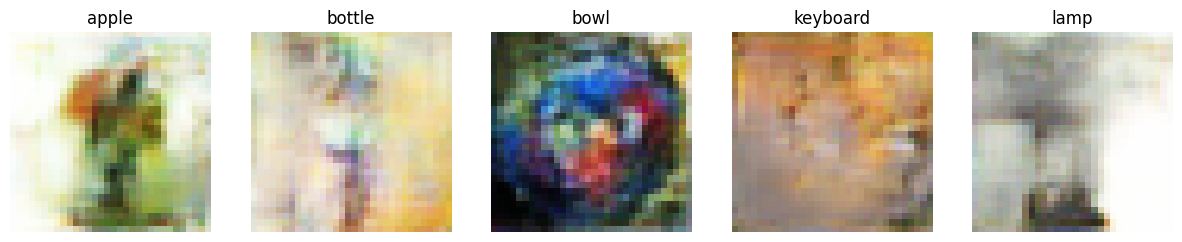

Epoch [241/300] Loss_D: 1.2248 Loss_G: 0.7904
Epoch [242/300] Loss_D: 1.5652 Loss_G: 1.0408
Epoch [243/300] Loss_D: 1.2678 Loss_G: 1.4777
Epoch [244/300] Loss_D: 1.6350 Loss_G: 0.9118
Epoch [245/300] Loss_D: 1.3278 Loss_G: 1.5981
Epoch [246/300] Loss_D: 1.3503 Loss_G: 0.7009
Epoch [247/300] Loss_D: 1.2417 Loss_G: 1.5103
Epoch [248/300] Loss_D: 1.3107 Loss_G: 1.8830
Epoch [249/300] Loss_D: 1.2792 Loss_G: 2.0191
Epoch [250/300] Loss_D: 1.2822 Loss_G: 1.1928


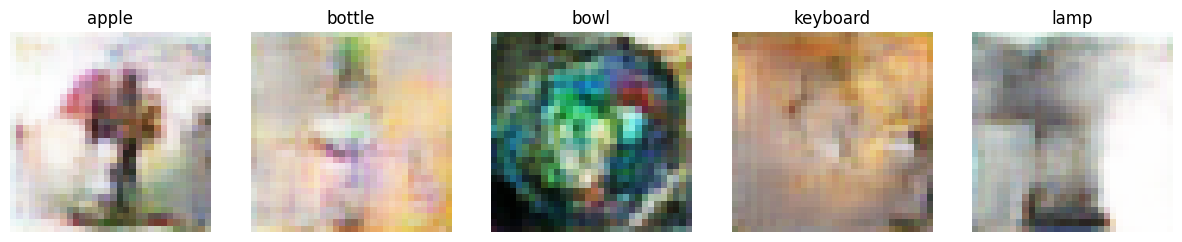

Epoch [251/300] Loss_D: 1.0717 Loss_G: 1.7122
Epoch [252/300] Loss_D: 1.1124 Loss_G: 1.8435
Epoch [253/300] Loss_D: 1.9311 Loss_G: 1.1381
Epoch [254/300] Loss_D: 1.4812 Loss_G: 1.0198
Epoch [255/300] Loss_D: 1.1990 Loss_G: 2.3740
Epoch [256/300] Loss_D: 1.1339 Loss_G: 1.8609
Epoch [257/300] Loss_D: 1.3462 Loss_G: 1.6787
Epoch [258/300] Loss_D: 1.2855 Loss_G: 1.0855
Epoch [259/300] Loss_D: 1.1969 Loss_G: 1.5590
Epoch [260/300] Loss_D: 1.3024 Loss_G: 1.1835


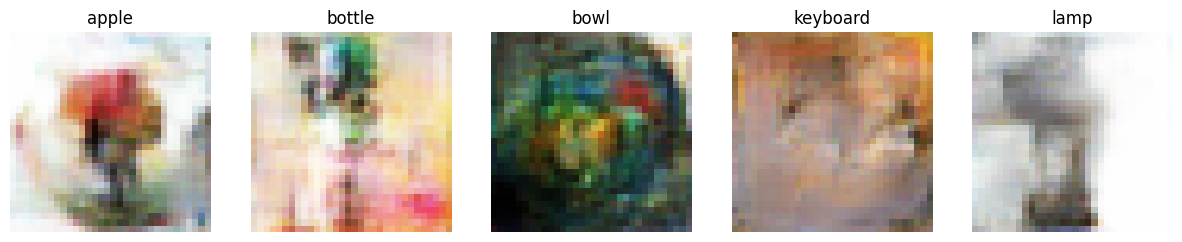

Epoch [261/300] Loss_D: 1.3732 Loss_G: 1.6432
Epoch [262/300] Loss_D: 1.3046 Loss_G: 1.2358
Epoch [263/300] Loss_D: 1.4624 Loss_G: 2.7169
Epoch [264/300] Loss_D: 1.3336 Loss_G: 1.1738
Epoch [265/300] Loss_D: 1.0238 Loss_G: 1.4822
Epoch [266/300] Loss_D: 1.3529 Loss_G: 1.8429
Epoch [267/300] Loss_D: 1.2983 Loss_G: 1.2024
Epoch [268/300] Loss_D: 1.3433 Loss_G: 1.1543
Epoch [269/300] Loss_D: 0.9062 Loss_G: 2.8526
Epoch [270/300] Loss_D: 1.2877 Loss_G: 1.2743


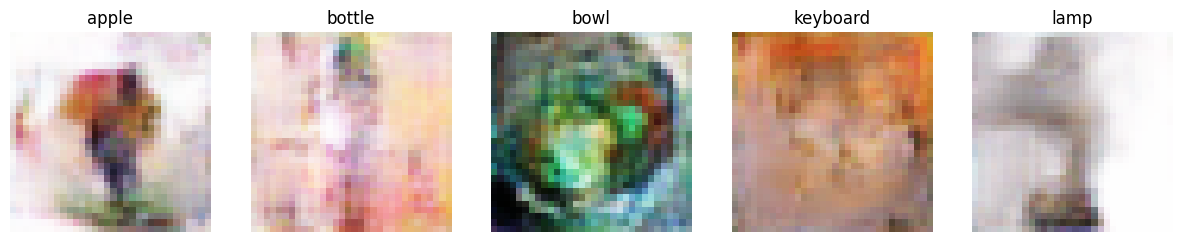

Epoch [271/300] Loss_D: 1.0020 Loss_G: 1.4515
Epoch [272/300] Loss_D: 1.1329 Loss_G: 1.6939
Epoch [273/300] Loss_D: 1.0314 Loss_G: 1.4506
Epoch [274/300] Loss_D: 1.6142 Loss_G: 1.6186
Epoch [275/300] Loss_D: 1.4236 Loss_G: 1.1654
Epoch [276/300] Loss_D: 1.1035 Loss_G: 1.5370
Epoch [277/300] Loss_D: 1.0186 Loss_G: 2.2970
Epoch [278/300] Loss_D: 1.5172 Loss_G: 2.1778
Epoch [279/300] Loss_D: 1.1104 Loss_G: 1.7249
Epoch [280/300] Loss_D: 1.6289 Loss_G: 1.0868


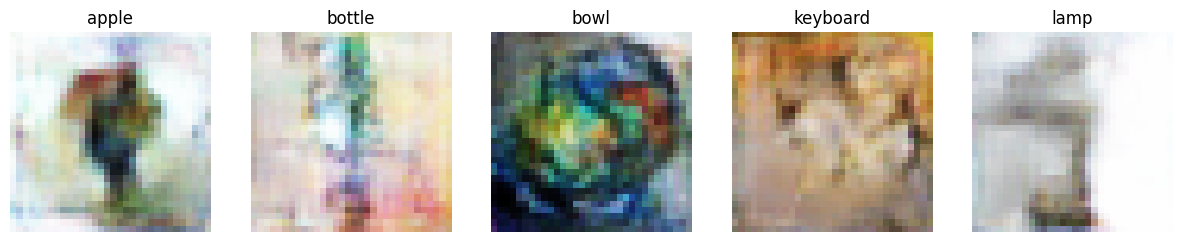

Epoch [281/300] Loss_D: 1.1797 Loss_G: 1.6508
Epoch [282/300] Loss_D: 1.3364 Loss_G: 1.6958
Epoch [283/300] Loss_D: 1.3018 Loss_G: 1.4905
Epoch [284/300] Loss_D: 1.5433 Loss_G: 0.8825
Epoch [285/300] Loss_D: 1.0805 Loss_G: 1.7268
Epoch [286/300] Loss_D: 1.2359 Loss_G: 1.0006
Epoch [287/300] Loss_D: 1.3365 Loss_G: 2.9347
Epoch [288/300] Loss_D: 1.5012 Loss_G: 1.8535
Epoch [289/300] Loss_D: 1.3850 Loss_G: 1.8129
Epoch [290/300] Loss_D: 1.3528 Loss_G: 1.1867


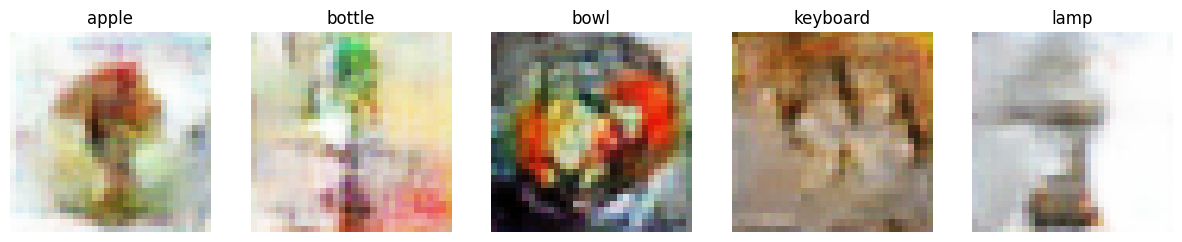

Epoch [291/300] Loss_D: 0.9684 Loss_G: 2.2493
Epoch [292/300] Loss_D: 1.1472 Loss_G: 1.3230
Epoch [293/300] Loss_D: 1.5462 Loss_G: 0.7473
Epoch [294/300] Loss_D: 1.7728 Loss_G: 1.7155
Epoch [295/300] Loss_D: 1.3018 Loss_G: 1.5350
Epoch [296/300] Loss_D: 1.1789 Loss_G: 1.3744
Epoch [297/300] Loss_D: 1.0128 Loss_G: 1.8412
Epoch [298/300] Loss_D: 1.3987 Loss_G: 2.5739
Epoch [299/300] Loss_D: 1.4475 Loss_G: 1.5927
Epoch [300/300] Loss_D: 1.7146 Loss_G: 2.6271


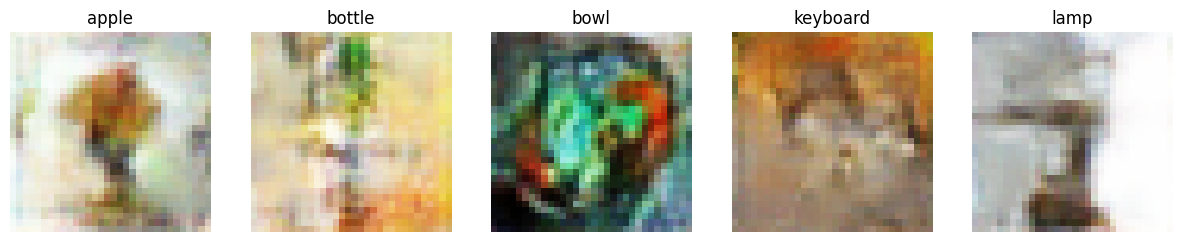

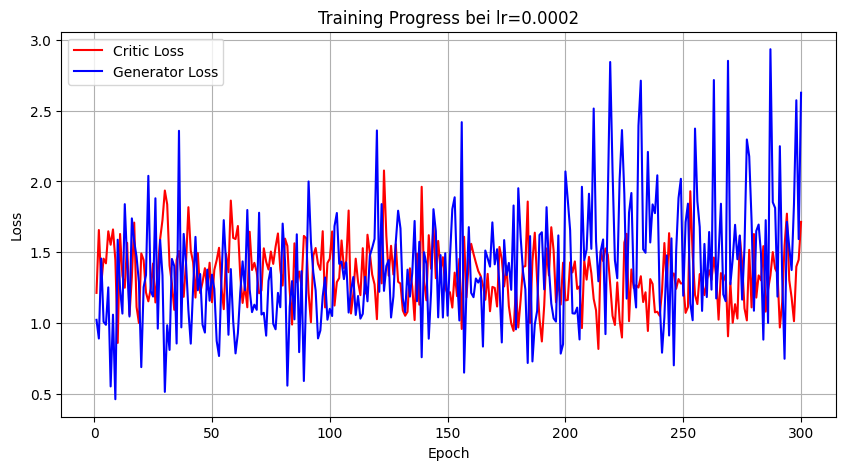

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 64
lr = 0.0002
n_epochs = 300
noise_dim = 100
img_size = 32
channels = 3

G_losses = []
D_losses = []

selected_classes = ['apple', 'bottle', 'bowl', 'keyboard', 'lamp']

# Labels mapping: Label-Namen → Index 0-4
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(selected_classes)}

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

full_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
# Filter nur nach ausgewählten Klassen
indices = [i for i, (_, label) in enumerate(full_dataset) if full_dataset.classes[label] in selected_classes]
filtered_dataset = Subset(full_dataset, indices)

# Labels als Indizes 0-4 passend zu selected_classes
class FilteredDataset(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        label_name = full_dataset.classes[label]
        label_idx = class_to_idx[label_name]
        return img, label_idx

train_loader = DataLoader(FilteredDataset(filtered_dataset), batch_size=batch_size, shuffle=True)

# Generator mit Label-Embedding
class Generator(nn.Module):
    def __init__(self, noise_dim, n_classes, img_size, channels):
        super().__init__()
        self.init_size = img_size // 4
        self.label_emb = nn.Embedding(n_classes, n_classes)  # One-Hot Art Embedding

        self.l1 = nn.Sequential(nn.Linear(noise_dim + n_classes, 128 * self.init_size ** 2))

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128, 0.8),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.ReLU(True),
            nn.Conv2d(64, channels, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_embedding = self.label_emb(labels)
        x = torch.cat([noise, label_embedding], dim=1)
        out = self.l1(x)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

# Discriminator mit Label-Embedding als zusätzlichen Kanal
class Discriminator(nn.Module):
    def __init__(self, n_classes, img_size, channels):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, n_classes)
        self.img_size = img_size

        self.model = nn.Sequential(
            nn.Conv2d(channels + n_classes, 64, 3, 2, 1),  # Input channels + n_classes
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * (img_size // 4) * (img_size // 4), 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_embedding = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        label_embedding = label_embedding.expand(labels.size(0), label_embedding.size(1), self.img_size, self.img_size)
        d_in = torch.cat([img, label_embedding], dim=1)
        return self.model(d_in)

generator = Generator(noise_dim, len(selected_classes), img_size, channels).to(device)
discriminator = Discriminator(len(selected_classes), img_size, channels).to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

real_label = 1.
fake_label = 0.

fixed_noise = torch.randn(len(selected_classes), noise_dim, device=device)
fixed_labels = torch.arange(len(selected_classes), device=device)

for epoch in range(n_epochs):
    for i, (imgs, labels) in enumerate(train_loader):
        imgs = imgs.to(device)
        labels = labels.to(device)
        batch_size_curr = imgs.size(0)

        # Discriminator trainieren
        discriminator.zero_grad()
        labels_real = torch.full((batch_size_curr, 1), real_label, device=device)
        output_real = discriminator(imgs, labels)
        loss_real = criterion(output_real, labels_real)

        noise = torch.randn(batch_size_curr, noise_dim, device=device)
        fake_imgs = generator(noise, labels)
        labels_fake = torch.full((batch_size_curr, 1), fake_label, device=device)
        output_fake = discriminator(fake_imgs.detach(), labels)
        loss_fake = criterion(output_fake, labels_fake)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # Generator trainieren
        generator.zero_grad()
        labels_gen = torch.full((batch_size_curr, 1), real_label, device=device)
        output_gen = discriminator(fake_imgs, labels)
        loss_G = criterion(output_gen, labels_gen)
        loss_G.backward()
        optimizer_G.step()

    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())

    print(f"Epoch [{epoch+1}/{n_epochs}] Loss_D: {loss_D.item():.4f} Loss_G: {loss_G.item():.4f}")

    if (epoch+1) % 10 == 0:
        generator.eval()
        with torch.no_grad():
            gen_imgs = generator(fixed_noise, fixed_labels).cpu()
            save_generated_images(generator, noise_dim, selected_classes, device, epoch+1, save_dir="./generated_images/cgan")
        generator.train()

        fig, axs = plt.subplots(1, len(selected_classes), figsize=(15, 3))
        for i in range(len(selected_classes)):
            img = gen_imgs[i] * 0.5 + 0.5
            img = img.permute(1, 2, 0).numpy()
            axs[i].imshow(img)
            axs[i].axis('off')
            axs[i].set_title(selected_classes[i])
        plt.show()

# Plotten des Trainings
plot_training_progress(D_losses, G_losses, lr=lr)

# **Conditional GAN mit ResBlöcken, Self-Attention und Hinge Loss auf CIFAR-100Subklassen**

## **1. Überblick**

Ziel dieses Abschnitts ist die Implementierung eines leistungsfähigeren *Conditional GANs* (cGAN), das realistische Bilder für fünf ausgewählte Klassen aus dem CIFAR-100-Datensatz generieren kann:

```
['apple', 'bottle', 'bowl', 'keyboard', 'lamp']
```

Um dieses Ziel zu erreichen basiert die Architektur auf Ideen aus **BigGAN**:

* Verwendung von **ResNet-Blöcken** im Generator und Diskriminator
* **Conditional BatchNorm** im Generator
* **Self-Attention Layer** für globale Kontextverarbeitung
* **Projection Discriminator**
* Verwendung von **Hinge Loss**, wie in modernen GANs üblich

---

## **2. Datensatzvorverarbeitung**

Verwendet wird der **CIFAR-100-Datensatz**, jedoch beschränkt auf fünf Objektklassen. Die Daten werden normalisiert ($-1, 1$) und durch ein eigenes Dataset-Wrapper (`FilteredDataset`) auf ein Label-Index-Mapping `[0-4]` abgebildet.

```python
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
```

---

## **3. Modellarchitektur**

### **3.1 Generator**

Der Generator nutzt folgende Kernkomponenten:

* **Latentraum** $z \in \mathbb{R}^{128}$
* **Linear Layer** zur Transformation von z auf eine 4×4 Featuremap
* Drei **Residual Upsampling Blocks** mit **Conditional BatchNorm**
* **Self-Attention** nach dem zweiten Block
* Finaler Conv-Layer mit `Tanh()` zur Bildausgabe (32×32×3)

#### Bedingung:

Jede Schicht verwendet **Conditional BatchNorm**, um Klassenspezifität zu erreichen.

---

### **3.2 Diskriminator**

Der Diskriminator nutzt:

* **Residual Downsampling Blocks**
* **Self-Attention Layer** auf 4×4-Featuremap
* Finales Flatten und FC-Layer

#### **Projection Mechanismus**:

Ein *Klasseneinbettungs-Vektor* wird auf den Output des Netzes projiziert:

```python
out_linear + (out * embed).sum(1)
```

Dies ermöglicht *klassenspezifische Entscheidungsfindung*.

---

## **4. Besonderheiten der Architektur**

| Komponente                   | Funktion                                              |
| ---------------------------- | ----------------------------------------------------- |
| **Conditional BatchNorm**    | Bedingte Normalisierung auf Klassenebene im Generator |
| **Residual Blocks**          | Stabilere Gradienten, tiefere Netzstruktur            |
| **Self-Attention**           | Berücksichtigung globaler Abhängigkeiten              |
| **Spectral Normalization**   | Kontrolle der Lipschitz-Konstanten im Diskriminator   |
| **Projection Discriminator** | Verknüpft Bildrepräsentationen mit Label-Embedding    |

---

## **5. Verlustfunktion**

Anstelle klassischer Binary Cross-Entropy werden **Hinge Losses** verwendet, wie in BigGAN und anderen SOTA-Modellen üblich.

```python
def d_loss_hinge(real_pred, fake_pred):
    return torch.mean(F.relu(1. - real_pred)) + torch.mean(F.relu(1. + fake_pred))

def g_loss_hinge(fake_pred):
    return -torch.mean(fake_pred)
```

---

## **6. Training**

* **Optimierer**: Adam mit $\beta_1 = 0.0$, $\beta_2 = 0.9$
* **Lernrate**: 2e-4
* **Batchgröße**: 64
* **Epochen**: 300
* **Zufallsvektor**: `z_dim = 128`
* **Gerät**: GPU (falls verfügbar)

### **Trainingsloop**

In jedem Trainingsschritt werden:

* Diskriminator auf echte und gefälschte Bilder trainiert
* Generator darauf trainiert, den Diskriminator zu täuschen

### **Visualisierung**

Alle 10 Epochen werden Beispielbilder zu jeder Klasse erzeugt und angezeigt. Dafür wird ein fester Noise- und Label-Satz verwendet:

```python
fixed_noise = torch.randn(n_classes, z_dim, device=device)
fixed_labels = torch.arange(n_classes, device=device)
```

---

## **7. Ergebnisse & Beobachtungen**

* Die Architektur ist deutlich ausdrucksstärker als eine einfache cGAN-Version.
* Durch Self-Attention und ResBlöcke werden klarerere Strukturen generiert.
* Einige Klassen (z. B. „apple“ oder „bottle“) zeigen eine konsistente Repräsentation, andere (z. B. „keyboard“) profitieren nicht sofort vom Training — evtl. wegen geringer Varianz im CIFAR-100. Dabei zeigt sich Parallelität zu dem simpleren cGAN aus dem vorherhigen Abschnitt.
* Die Lernkurven zeigen deutliches Lernen beim Generator, jedoch auch bekannte Instabilitäten (typisch bei GANs).

---

## **8. Mögliche Erweiterungen**

* **FID-Score Berechnung** zur objektiven Qualitätsbewertung
* Training auf größerem Datensatz oder mehr Klassen
* Einführung eines **Two-Time-Scale-Update-Rules** (TTUR)
* Integration in ein Framework wie `torchgan` oder `lucidrain`

---

## **9. Fazit**

Die Implementierung eines BigGAN-ähnlichen cGAN auf CIFAR-100 demonstriert die Leistungsfähigkeit moderner Architekturen. Sie bietet solide bis gute Ergebnisse bei der konditionalen Generierung und nutzt fortgeschrittene Techniken wie Attention, Projection Discriminator und ResBlöcke effektiv. Das Modell ist eine solide Basis für weiterführende Forschung im Bereich bedingter Bildsynthese.


Epoch [1/300] Loss_D: 1.7719, Loss_G: 2.2061
Epoch [2/300] Loss_D: 1.8503, Loss_G: 0.4693
Epoch [3/300] Loss_D: 2.0752, Loss_G: -0.3049
Epoch [4/300] Loss_D: 2.4737, Loss_G: 0.2994
Epoch [5/300] Loss_D: 1.6264, Loss_G: 0.5651
Epoch [6/300] Loss_D: 1.6315, Loss_G: 0.4311
Epoch [7/300] Loss_D: 2.2339, Loss_G: -0.0466
Epoch [8/300] Loss_D: 1.8789, Loss_G: 0.5049
Epoch [9/300] Loss_D: 1.9968, Loss_G: 0.0134
Epoch [10/300] Loss_D: 2.1346, Loss_G: 0.3501


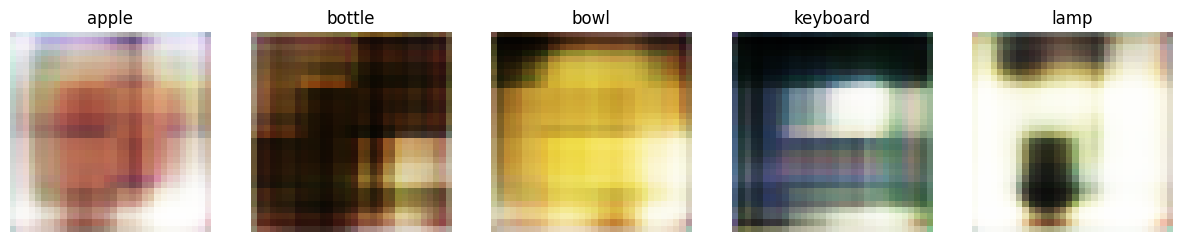

Epoch [11/300] Loss_D: 1.5649, Loss_G: 1.4634
Epoch [12/300] Loss_D: 1.8749, Loss_G: 0.7655
Epoch [13/300] Loss_D: 2.0459, Loss_G: 0.2056
Epoch [14/300] Loss_D: 1.8725, Loss_G: 0.6294
Epoch [15/300] Loss_D: 1.8785, Loss_G: 0.6902
Epoch [16/300] Loss_D: 1.7561, Loss_G: 0.3246
Epoch [17/300] Loss_D: 1.8296, Loss_G: 0.2825
Epoch [18/300] Loss_D: 1.9065, Loss_G: 0.7685
Epoch [19/300] Loss_D: 2.7472, Loss_G: 0.6671
Epoch [20/300] Loss_D: 2.2804, Loss_G: 0.2717


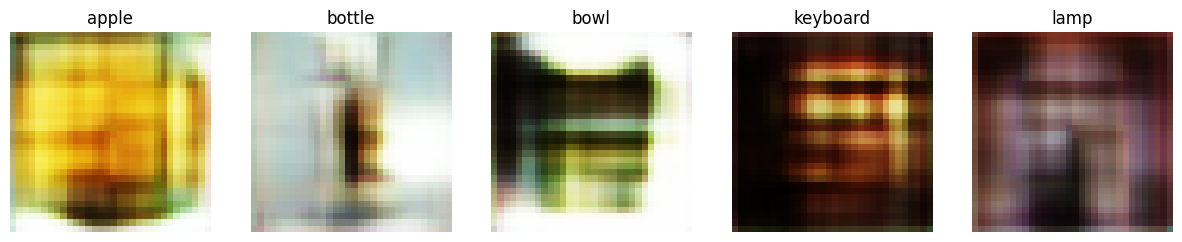

Epoch [21/300] Loss_D: 2.2456, Loss_G: 0.3693
Epoch [22/300] Loss_D: 1.7716, Loss_G: 1.2672
Epoch [23/300] Loss_D: 2.0731, Loss_G: 0.4042
Epoch [24/300] Loss_D: 1.8797, Loss_G: -0.1850
Epoch [25/300] Loss_D: 2.2104, Loss_G: 0.1250
Epoch [26/300] Loss_D: 2.3614, Loss_G: 0.1463
Epoch [27/300] Loss_D: 2.0812, Loss_G: 0.3855
Epoch [28/300] Loss_D: 2.1462, Loss_G: 0.3803
Epoch [29/300] Loss_D: 1.5542, Loss_G: -0.9071
Epoch [30/300] Loss_D: 2.2852, Loss_G: 0.7888


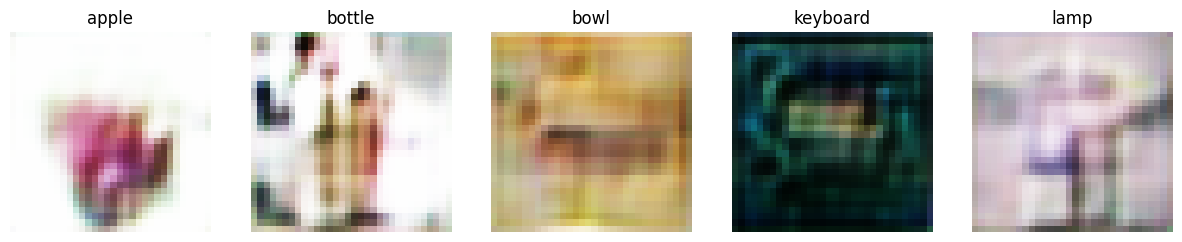

Epoch [31/300] Loss_D: 1.7325, Loss_G: 0.8056
Epoch [32/300] Loss_D: 1.7987, Loss_G: 0.6352
Epoch [33/300] Loss_D: 2.2519, Loss_G: -0.5572
Epoch [34/300] Loss_D: 2.0495, Loss_G: 0.3008
Epoch [35/300] Loss_D: 2.3213, Loss_G: 0.3021
Epoch [36/300] Loss_D: 2.1173, Loss_G: 0.2516
Epoch [37/300] Loss_D: 2.0463, Loss_G: -0.1474
Epoch [38/300] Loss_D: 1.9905, Loss_G: -1.2093
Epoch [39/300] Loss_D: 2.0414, Loss_G: -0.2309
Epoch [40/300] Loss_D: 2.1438, Loss_G: 0.3439


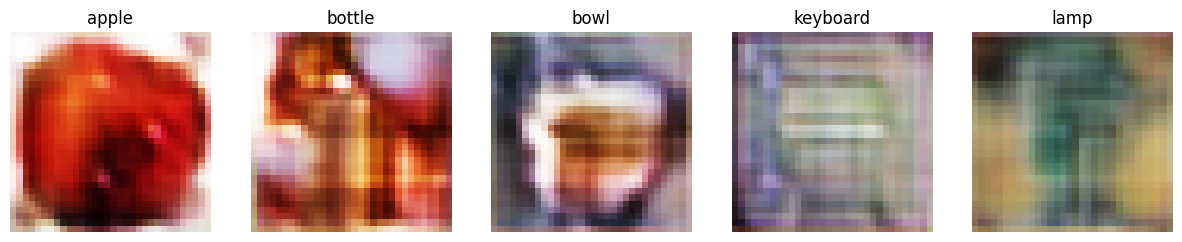

Epoch [41/300] Loss_D: 1.8471, Loss_G: 0.9009
Epoch [42/300] Loss_D: 2.0707, Loss_G: 0.5969
Epoch [43/300] Loss_D: 1.6306, Loss_G: 1.6421
Epoch [44/300] Loss_D: 1.6806, Loss_G: 1.2533
Epoch [45/300] Loss_D: 2.1563, Loss_G: -0.0029
Epoch [46/300] Loss_D: 1.6246, Loss_G: 2.5944
Epoch [47/300] Loss_D: 1.3881, Loss_G: 0.3898
Epoch [48/300] Loss_D: 1.6885, Loss_G: 1.3234
Epoch [49/300] Loss_D: 1.4600, Loss_G: 0.2120
Epoch [50/300] Loss_D: 2.2563, Loss_G: 0.2701


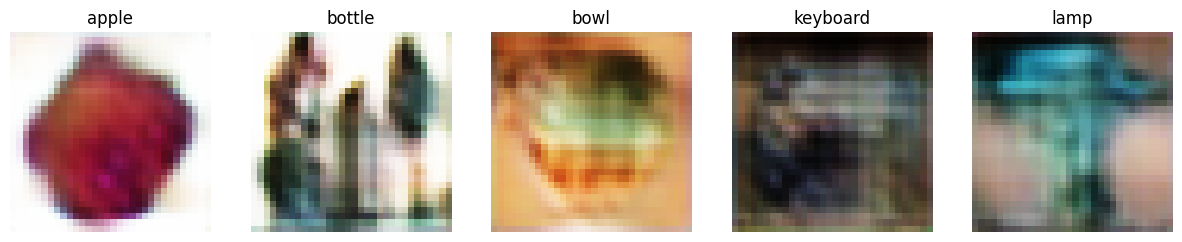

Epoch [51/300] Loss_D: 1.5187, Loss_G: 0.0162
Epoch [52/300] Loss_D: 1.9430, Loss_G: 0.2471
Epoch [53/300] Loss_D: 1.6621, Loss_G: 0.2363
Epoch [54/300] Loss_D: 2.0523, Loss_G: -0.1904
Epoch [55/300] Loss_D: 1.4970, Loss_G: -0.8293
Epoch [56/300] Loss_D: 1.9336, Loss_G: 0.9916
Epoch [57/300] Loss_D: 1.9384, Loss_G: 0.4610
Epoch [58/300] Loss_D: 1.8279, Loss_G: 0.3671
Epoch [59/300] Loss_D: 1.6735, Loss_G: -0.2174
Epoch [60/300] Loss_D: 1.6822, Loss_G: 0.6469


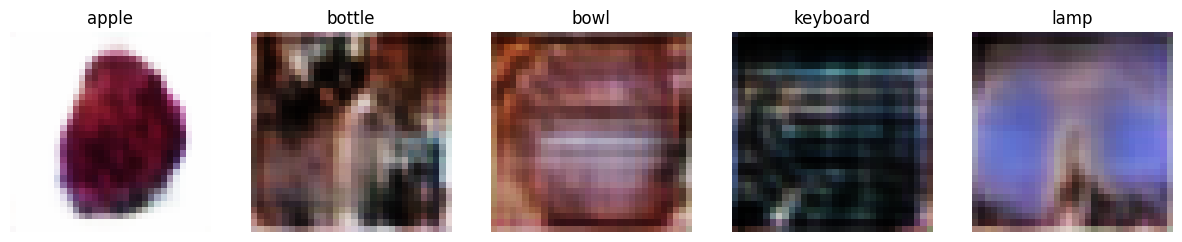

Epoch [61/300] Loss_D: 1.8962, Loss_G: 0.7301
Epoch [62/300] Loss_D: 1.1385, Loss_G: 1.0889
Epoch [63/300] Loss_D: 1.5183, Loss_G: -1.8392
Epoch [64/300] Loss_D: 1.2106, Loss_G: 1.3185
Epoch [65/300] Loss_D: 1.8584, Loss_G: 0.1622
Epoch [66/300] Loss_D: 2.1655, Loss_G: 0.0494
Epoch [67/300] Loss_D: 1.7764, Loss_G: 0.1809
Epoch [68/300] Loss_D: 1.7468, Loss_G: 0.5075
Epoch [69/300] Loss_D: 1.7752, Loss_G: 1.1567
Epoch [70/300] Loss_D: 1.6168, Loss_G: 0.4932


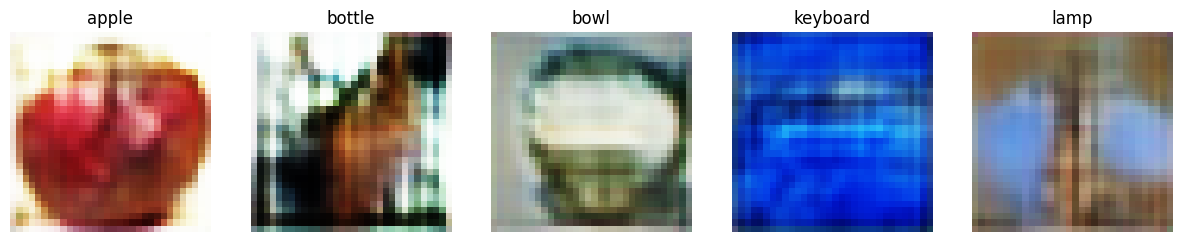

Epoch [71/300] Loss_D: 1.9687, Loss_G: 0.1372
Epoch [72/300] Loss_D: 1.3229, Loss_G: -0.5502
Epoch [73/300] Loss_D: 1.2440, Loss_G: 0.1991
Epoch [74/300] Loss_D: 1.3812, Loss_G: -0.8857
Epoch [75/300] Loss_D: 1.7095, Loss_G: 1.6981
Epoch [76/300] Loss_D: 1.3829, Loss_G: -0.7269
Epoch [77/300] Loss_D: 1.7811, Loss_G: 0.3891
Epoch [78/300] Loss_D: 2.8198, Loss_G: 0.6467
Epoch [79/300] Loss_D: 1.3943, Loss_G: 1.1736
Epoch [80/300] Loss_D: 2.0229, Loss_G: 0.5004


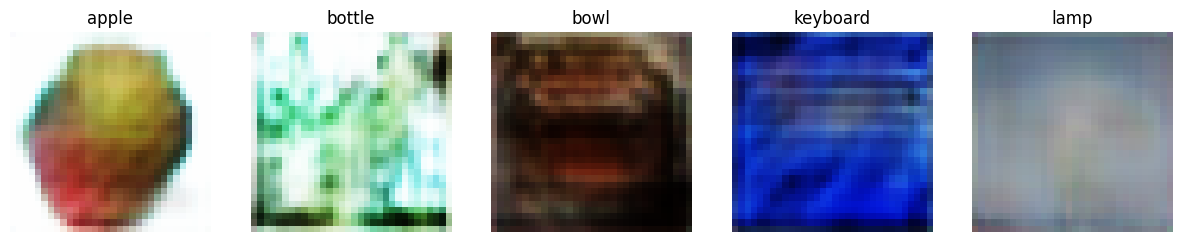

Epoch [81/300] Loss_D: 2.2923, Loss_G: 0.1914
Epoch [82/300] Loss_D: 0.9666, Loss_G: 0.6319
Epoch [83/300] Loss_D: 2.5374, Loss_G: -0.5480
Epoch [84/300] Loss_D: 1.3289, Loss_G: 0.3970
Epoch [85/300] Loss_D: 0.7821, Loss_G: 0.4538
Epoch [86/300] Loss_D: 1.2978, Loss_G: 0.4798
Epoch [87/300] Loss_D: 1.4545, Loss_G: 0.7315
Epoch [88/300] Loss_D: 1.0305, Loss_G: 2.0719
Epoch [89/300] Loss_D: 1.4507, Loss_G: -0.0748
Epoch [90/300] Loss_D: 1.1991, Loss_G: -0.2782


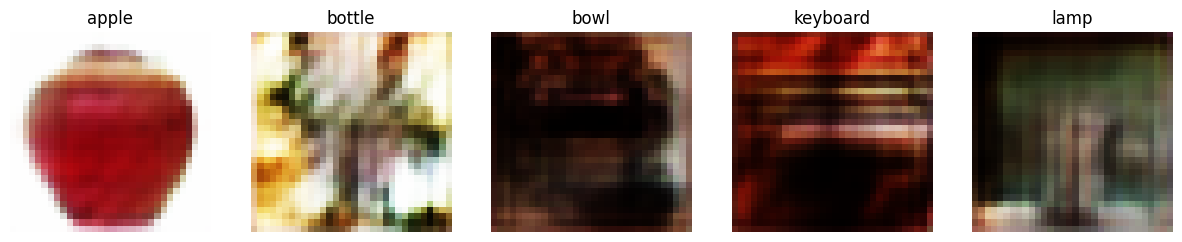

Epoch [91/300] Loss_D: 1.5848, Loss_G: -0.6367
Epoch [92/300] Loss_D: 1.1527, Loss_G: 1.1665
Epoch [93/300] Loss_D: 1.4138, Loss_G: 0.2605
Epoch [94/300] Loss_D: 2.1149, Loss_G: 1.0225
Epoch [95/300] Loss_D: 1.0189, Loss_G: 1.6605
Epoch [96/300] Loss_D: 0.9844, Loss_G: 1.2082
Epoch [97/300] Loss_D: 1.2976, Loss_G: 1.1811
Epoch [98/300] Loss_D: 1.2548, Loss_G: 0.0349
Epoch [99/300] Loss_D: 1.1363, Loss_G: 0.4641
Epoch [100/300] Loss_D: 1.1002, Loss_G: 0.3947


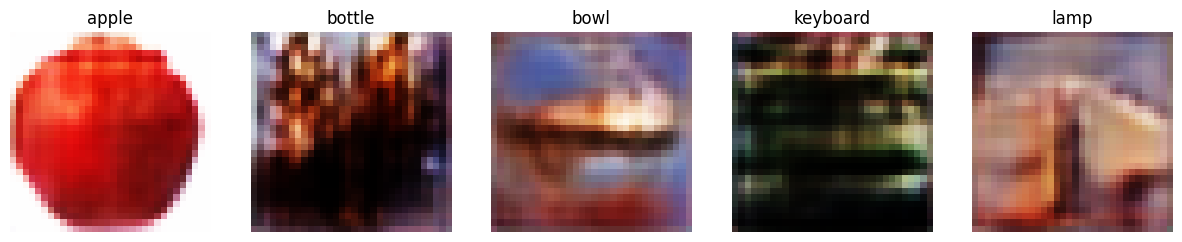

Epoch [101/300] Loss_D: 1.4363, Loss_G: 0.6504
Epoch [102/300] Loss_D: 1.3388, Loss_G: -0.0072
Epoch [103/300] Loss_D: 1.6899, Loss_G: 0.7798
Epoch [104/300] Loss_D: 1.2191, Loss_G: 0.2996
Epoch [105/300] Loss_D: 0.6865, Loss_G: -0.2716
Epoch [106/300] Loss_D: 1.8989, Loss_G: 0.5939
Epoch [107/300] Loss_D: 0.9634, Loss_G: 2.1514
Epoch [108/300] Loss_D: 1.4882, Loss_G: 0.6642
Epoch [109/300] Loss_D: 2.2529, Loss_G: -0.0845
Epoch [110/300] Loss_D: 1.1329, Loss_G: -0.5924


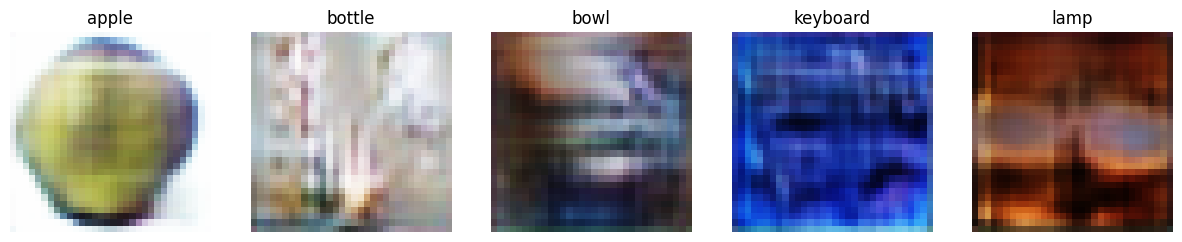

Epoch [111/300] Loss_D: 1.2145, Loss_G: 1.8287
Epoch [112/300] Loss_D: 0.8652, Loss_G: 1.8320
Epoch [113/300] Loss_D: 0.8743, Loss_G: -0.1445
Epoch [114/300] Loss_D: 1.0389, Loss_G: 0.1608
Epoch [115/300] Loss_D: 0.5634, Loss_G: 0.8438
Epoch [116/300] Loss_D: 1.2823, Loss_G: -0.8737
Epoch [117/300] Loss_D: 1.8679, Loss_G: 0.2384
Epoch [118/300] Loss_D: 1.0143, Loss_G: -0.2618
Epoch [119/300] Loss_D: 0.7032, Loss_G: 0.4169
Epoch [120/300] Loss_D: 1.1502, Loss_G: 1.3328


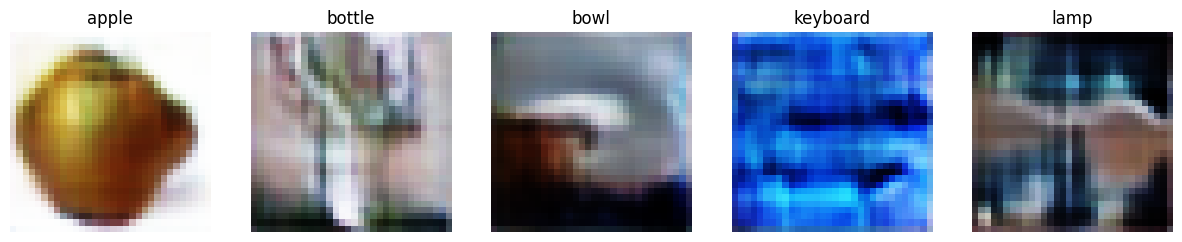

Epoch [121/300] Loss_D: 0.7531, Loss_G: 2.4957
Epoch [122/300] Loss_D: 0.7175, Loss_G: 0.3465
Epoch [123/300] Loss_D: 0.6287, Loss_G: 0.1191
Epoch [124/300] Loss_D: 0.5539, Loss_G: 0.1287
Epoch [125/300] Loss_D: 0.4130, Loss_G: 1.3046
Epoch [126/300] Loss_D: 0.5288, Loss_G: -0.1592
Epoch [127/300] Loss_D: 1.6381, Loss_G: 1.5165
Epoch [128/300] Loss_D: 0.3481, Loss_G: 0.9253
Epoch [129/300] Loss_D: 0.7323, Loss_G: 0.8086
Epoch [130/300] Loss_D: 1.7520, Loss_G: 0.5162


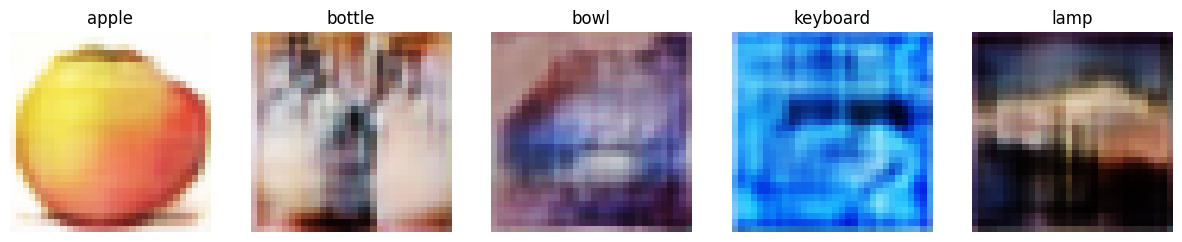

Epoch [131/300] Loss_D: 0.6549, Loss_G: 0.0832
Epoch [132/300] Loss_D: 0.8352, Loss_G: 0.8327
Epoch [133/300] Loss_D: 1.4656, Loss_G: 0.6703
Epoch [134/300] Loss_D: 0.8902, Loss_G: -0.2762
Epoch [135/300] Loss_D: 0.2706, Loss_G: 2.6307
Epoch [136/300] Loss_D: 1.0051, Loss_G: 0.8735
Epoch [137/300] Loss_D: 0.7492, Loss_G: 0.0814
Epoch [138/300] Loss_D: 0.6768, Loss_G: 0.1584
Epoch [139/300] Loss_D: 0.6073, Loss_G: 0.1289
Epoch [140/300] Loss_D: 0.8980, Loss_G: -0.3501


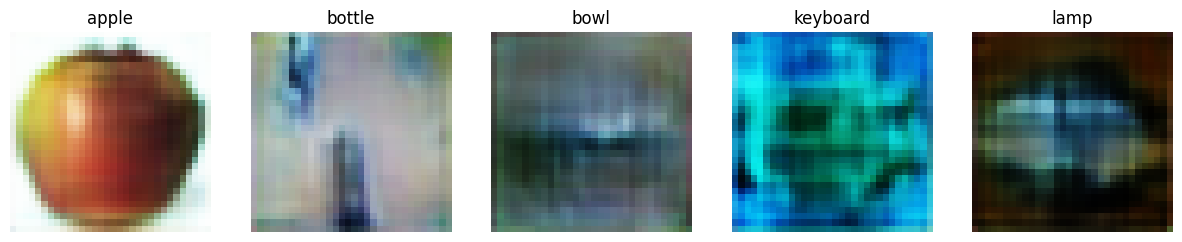

Epoch [141/300] Loss_D: 0.8148, Loss_G: 1.2008
Epoch [142/300] Loss_D: 1.4702, Loss_G: -0.2783
Epoch [143/300] Loss_D: 0.9513, Loss_G: 2.2462
Epoch [144/300] Loss_D: 0.8265, Loss_G: 1.7426
Epoch [145/300] Loss_D: 0.4811, Loss_G: -0.0294
Epoch [146/300] Loss_D: 1.0559, Loss_G: 3.2529
Epoch [147/300] Loss_D: 0.8450, Loss_G: 0.1649
Epoch [148/300] Loss_D: 1.0716, Loss_G: 0.4134
Epoch [149/300] Loss_D: 0.4236, Loss_G: 0.1559
Epoch [150/300] Loss_D: 0.3740, Loss_G: 0.5631


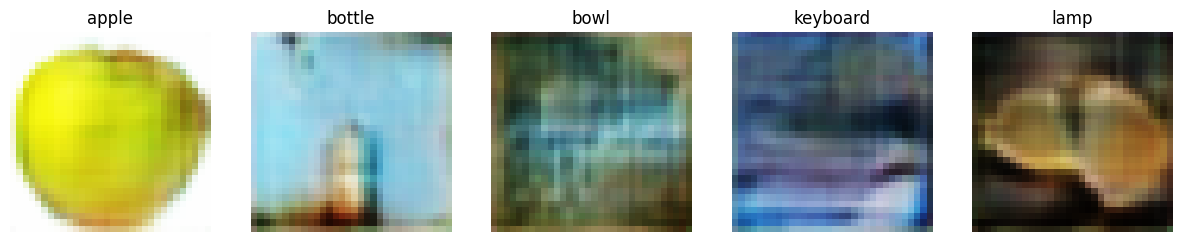

Epoch [151/300] Loss_D: 0.5796, Loss_G: -1.5280
Epoch [152/300] Loss_D: 0.4787, Loss_G: 1.3584
Epoch [153/300] Loss_D: 0.4438, Loss_G: 2.0860
Epoch [154/300] Loss_D: 0.6450, Loss_G: 0.2390
Epoch [155/300] Loss_D: 1.0671, Loss_G: 0.5719
Epoch [156/300] Loss_D: 0.4111, Loss_G: 2.0569
Epoch [157/300] Loss_D: 0.9897, Loss_G: 0.1261
Epoch [158/300] Loss_D: 0.8096, Loss_G: -0.6091
Epoch [159/300] Loss_D: 0.6157, Loss_G: 2.0542
Epoch [160/300] Loss_D: 0.7179, Loss_G: 0.6385


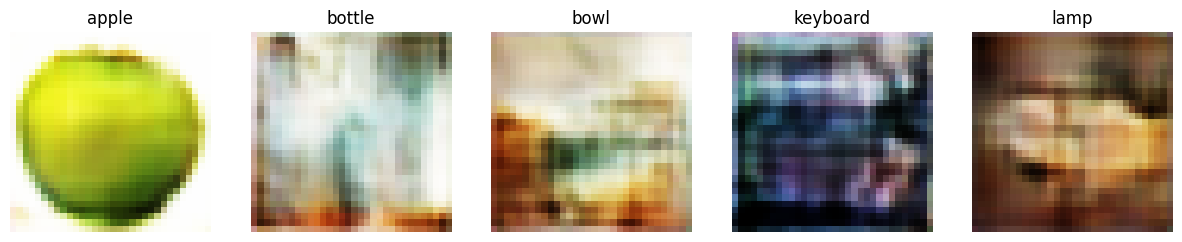

Epoch [161/300] Loss_D: 0.5121, Loss_G: 2.2528
Epoch [162/300] Loss_D: 0.7173, Loss_G: 3.6822
Epoch [163/300] Loss_D: 0.8409, Loss_G: 2.9016
Epoch [164/300] Loss_D: 1.4894, Loss_G: 1.3041
Epoch [165/300] Loss_D: 0.4897, Loss_G: 1.7830
Epoch [166/300] Loss_D: 0.5441, Loss_G: 2.3418
Epoch [167/300] Loss_D: 0.5496, Loss_G: 1.1882
Epoch [168/300] Loss_D: 1.1079, Loss_G: 0.1746
Epoch [169/300] Loss_D: 0.5225, Loss_G: 3.1666
Epoch [170/300] Loss_D: 0.9752, Loss_G: 0.2005


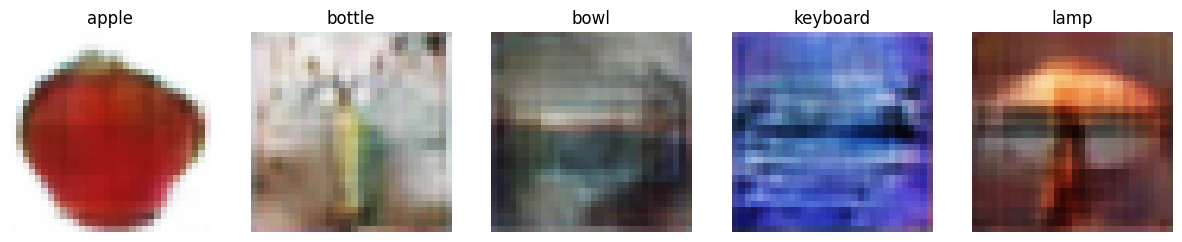

Epoch [171/300] Loss_D: 0.5800, Loss_G: 2.5042
Epoch [172/300] Loss_D: 0.5398, Loss_G: 1.4805
Epoch [173/300] Loss_D: 0.4568, Loss_G: 0.3236
Epoch [174/300] Loss_D: 1.1002, Loss_G: -0.2906
Epoch [175/300] Loss_D: 0.8317, Loss_G: 0.8438
Epoch [176/300] Loss_D: 0.2174, Loss_G: 0.8044
Epoch [177/300] Loss_D: 0.6919, Loss_G: 2.0931
Epoch [178/300] Loss_D: 0.3607, Loss_G: 0.6646
Epoch [179/300] Loss_D: 0.5356, Loss_G: 1.9758
Epoch [180/300] Loss_D: 0.6656, Loss_G: 3.8202


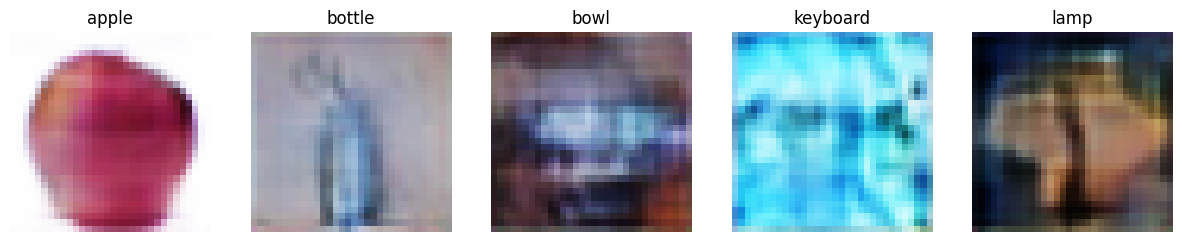

Epoch [181/300] Loss_D: 0.2143, Loss_G: 0.1760
Epoch [182/300] Loss_D: 0.5072, Loss_G: 2.2673
Epoch [183/300] Loss_D: 0.0000, Loss_G: 1.8836
Epoch [184/300] Loss_D: 0.1138, Loss_G: 1.6003
Epoch [185/300] Loss_D: 0.3579, Loss_G: 2.3575
Epoch [186/300] Loss_D: 1.0859, Loss_G: 1.9181
Epoch [187/300] Loss_D: 0.3990, Loss_G: 1.8642
Epoch [188/300] Loss_D: 0.9687, Loss_G: 1.2753
Epoch [189/300] Loss_D: 0.4413, Loss_G: 1.1817
Epoch [190/300] Loss_D: 0.5706, Loss_G: 1.7780


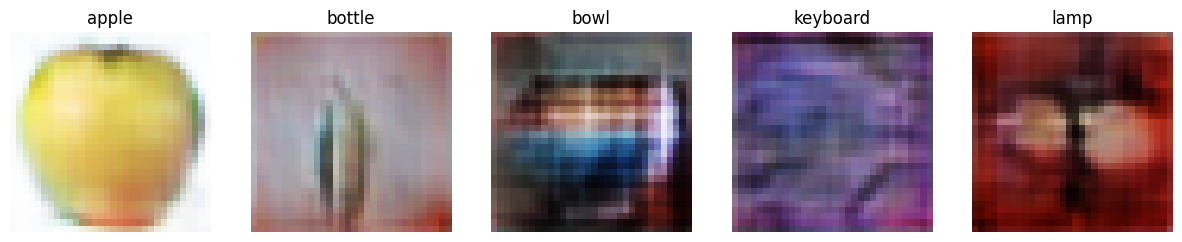

Epoch [191/300] Loss_D: 0.1968, Loss_G: 1.9412
Epoch [192/300] Loss_D: 0.2712, Loss_G: -0.0445
Epoch [193/300] Loss_D: 0.5878, Loss_G: 1.3376
Epoch [194/300] Loss_D: 0.0131, Loss_G: 1.3431
Epoch [195/300] Loss_D: 0.1960, Loss_G: 1.6344
Epoch [196/300] Loss_D: 0.7986, Loss_G: 1.6119
Epoch [197/300] Loss_D: 1.1643, Loss_G: 2.2773
Epoch [198/300] Loss_D: 0.1926, Loss_G: 1.3823
Epoch [199/300] Loss_D: 0.6379, Loss_G: 1.5543
Epoch [200/300] Loss_D: 0.2868, Loss_G: 2.9677


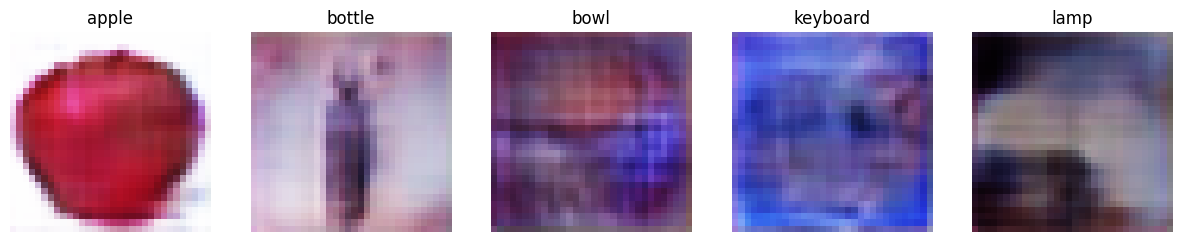

Epoch [201/300] Loss_D: 0.8156, Loss_G: 1.0106
Epoch [202/300] Loss_D: 0.7314, Loss_G: 3.1954
Epoch [203/300] Loss_D: 0.4944, Loss_G: 0.8483
Epoch [204/300] Loss_D: 0.3503, Loss_G: 1.6843
Epoch [205/300] Loss_D: 0.2983, Loss_G: 2.6567
Epoch [206/300] Loss_D: 0.8905, Loss_G: 0.3188
Epoch [207/300] Loss_D: 0.4953, Loss_G: 0.3951
Epoch [208/300] Loss_D: 0.1915, Loss_G: 0.2924
Epoch [209/300] Loss_D: 0.7467, Loss_G: 0.8046
Epoch [210/300] Loss_D: 0.3530, Loss_G: 2.0457


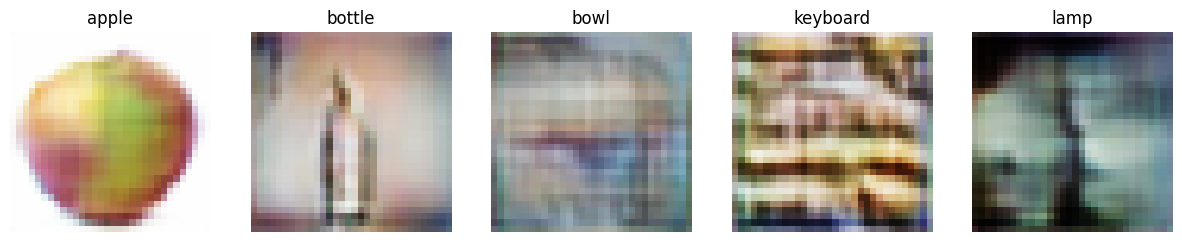

Epoch [211/300] Loss_D: 0.7391, Loss_G: 0.3483
Epoch [212/300] Loss_D: 0.0000, Loss_G: 2.4364
Epoch [213/300] Loss_D: 0.4161, Loss_G: 0.0139
Epoch [214/300] Loss_D: 0.1908, Loss_G: 0.9207
Epoch [215/300] Loss_D: 0.0000, Loss_G: 1.1321
Epoch [216/300] Loss_D: 0.2976, Loss_G: 2.4991
Epoch [217/300] Loss_D: 0.2303, Loss_G: 1.0637
Epoch [218/300] Loss_D: 0.2443, Loss_G: 0.5795
Epoch [219/300] Loss_D: 0.0000, Loss_G: 2.1912
Epoch [220/300] Loss_D: 0.1229, Loss_G: 3.0283


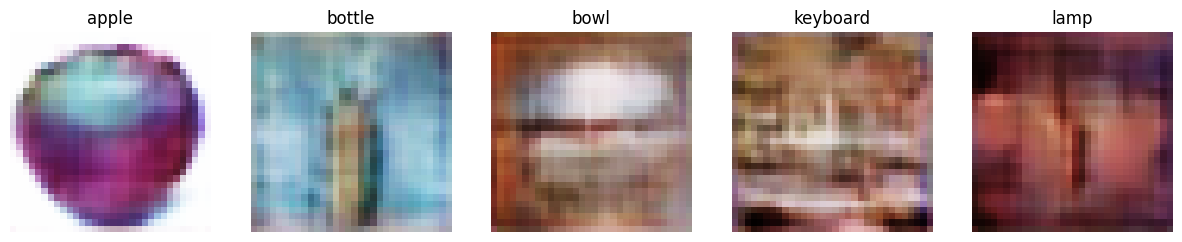

Epoch [221/300] Loss_D: 0.2982, Loss_G: 2.1908
Epoch [222/300] Loss_D: 0.3833, Loss_G: 1.8961
Epoch [223/300] Loss_D: 0.1106, Loss_G: 3.8336
Epoch [224/300] Loss_D: 0.0593, Loss_G: 2.4073
Epoch [225/300] Loss_D: 0.0156, Loss_G: 3.4959
Epoch [226/300] Loss_D: 0.3451, Loss_G: 2.9566
Epoch [227/300] Loss_D: 0.4255, Loss_G: 2.5559
Epoch [228/300] Loss_D: 0.0212, Loss_G: 2.7997
Epoch [229/300] Loss_D: 0.4430, Loss_G: 0.0457
Epoch [230/300] Loss_D: 0.6908, Loss_G: 0.6930


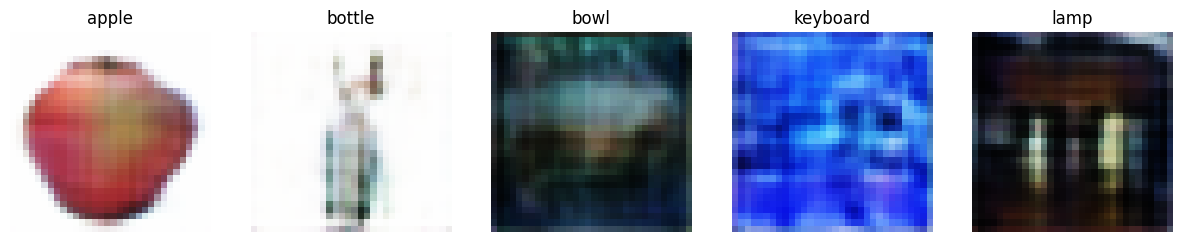

Epoch [231/300] Loss_D: 0.5818, Loss_G: -0.3878
Epoch [232/300] Loss_D: 0.1512, Loss_G: 1.2958
Epoch [233/300] Loss_D: 1.0437, Loss_G: 3.0333
Epoch [234/300] Loss_D: 0.2989, Loss_G: 3.2702
Epoch [235/300] Loss_D: 0.0371, Loss_G: 2.0948
Epoch [236/300] Loss_D: 0.3221, Loss_G: 1.5335
Epoch [237/300] Loss_D: 0.0260, Loss_G: 3.7718
Epoch [238/300] Loss_D: 0.0000, Loss_G: 2.4069
Epoch [239/300] Loss_D: 0.6014, Loss_G: 3.7595
Epoch [240/300] Loss_D: 0.6069, Loss_G: 3.1411


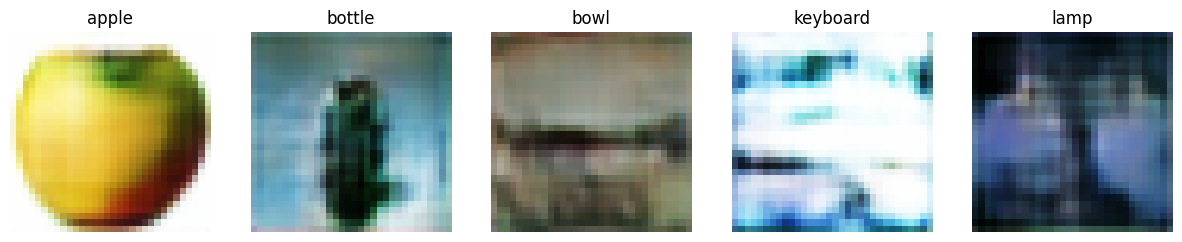

Epoch [241/300] Loss_D: 0.0888, Loss_G: 2.3833
Epoch [242/300] Loss_D: 0.8545, Loss_G: 1.9582
Epoch [243/300] Loss_D: 0.0000, Loss_G: 2.1267
Epoch [244/300] Loss_D: 0.0000, Loss_G: 2.6055
Epoch [245/300] Loss_D: 0.2091, Loss_G: 2.7725
Epoch [246/300] Loss_D: 0.0000, Loss_G: 1.4420
Epoch [247/300] Loss_D: 0.1687, Loss_G: 1.7718
Epoch [248/300] Loss_D: 0.1617, Loss_G: 2.0347
Epoch [249/300] Loss_D: 0.4055, Loss_G: -0.0404
Epoch [250/300] Loss_D: 0.0653, Loss_G: -1.4636


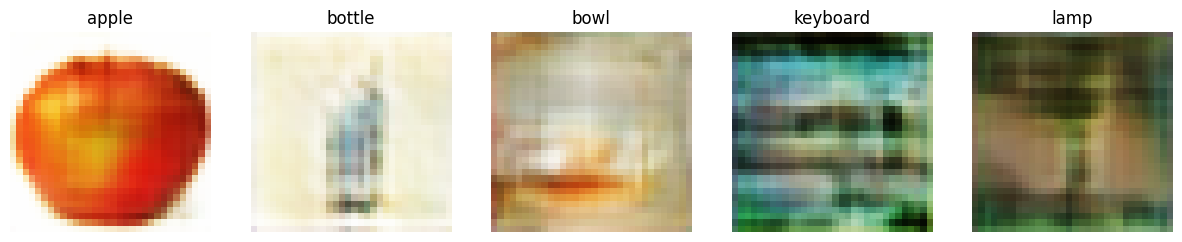

Epoch [251/300] Loss_D: 0.0498, Loss_G: 4.0396
Epoch [252/300] Loss_D: 0.0648, Loss_G: 1.9396
Epoch [253/300] Loss_D: 1.0810, Loss_G: 2.2087
Epoch [254/300] Loss_D: 0.0875, Loss_G: 0.7835
Epoch [255/300] Loss_D: 0.0451, Loss_G: 4.2271
Epoch [256/300] Loss_D: 0.1143, Loss_G: 2.7548
Epoch [257/300] Loss_D: 1.3008, Loss_G: 1.6002
Epoch [258/300] Loss_D: 0.3701, Loss_G: 3.9826
Epoch [259/300] Loss_D: 0.0783, Loss_G: 3.3445
Epoch [260/300] Loss_D: 0.2030, Loss_G: 2.7881


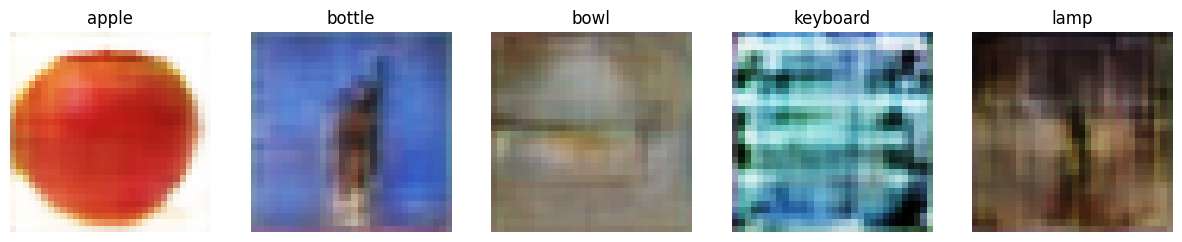

Epoch [261/300] Loss_D: 0.0000, Loss_G: 2.1923
Epoch [262/300] Loss_D: 0.2444, Loss_G: 3.2598
Epoch [263/300] Loss_D: 0.0789, Loss_G: 2.5540
Epoch [264/300] Loss_D: 0.2329, Loss_G: 2.5362
Epoch [265/300] Loss_D: 0.5194, Loss_G: -0.1823
Epoch [266/300] Loss_D: 0.3372, Loss_G: 2.8461
Epoch [267/300] Loss_D: 1.1173, Loss_G: 1.5389
Epoch [268/300] Loss_D: 0.7282, Loss_G: 1.4213
Epoch [269/300] Loss_D: 0.0000, Loss_G: 2.0868
Epoch [270/300] Loss_D: 0.0307, Loss_G: 4.4054


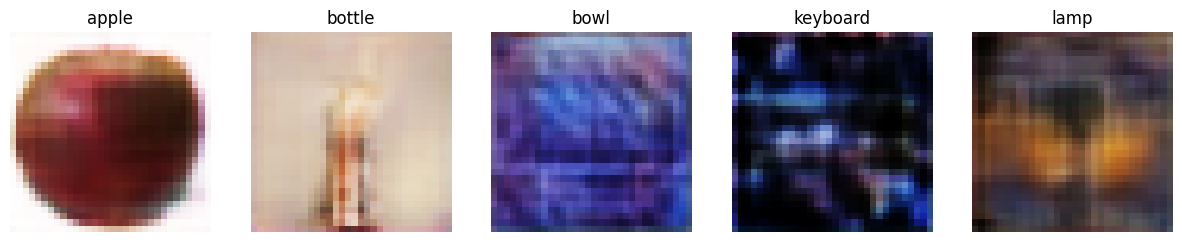

Epoch [271/300] Loss_D: 0.3419, Loss_G: 0.3130
Epoch [272/300] Loss_D: 0.1105, Loss_G: 1.6460
Epoch [273/300] Loss_D: 0.0157, Loss_G: 3.6449
Epoch [274/300] Loss_D: 0.9542, Loss_G: 1.0982
Epoch [275/300] Loss_D: 0.2076, Loss_G: 2.8526
Epoch [276/300] Loss_D: 0.6206, Loss_G: 2.2182
Epoch [277/300] Loss_D: 0.0000, Loss_G: 1.3876
Epoch [278/300] Loss_D: 0.8361, Loss_G: 1.1929
Epoch [279/300] Loss_D: 0.2204, Loss_G: 3.1850
Epoch [280/300] Loss_D: 0.2926, Loss_G: 3.5693


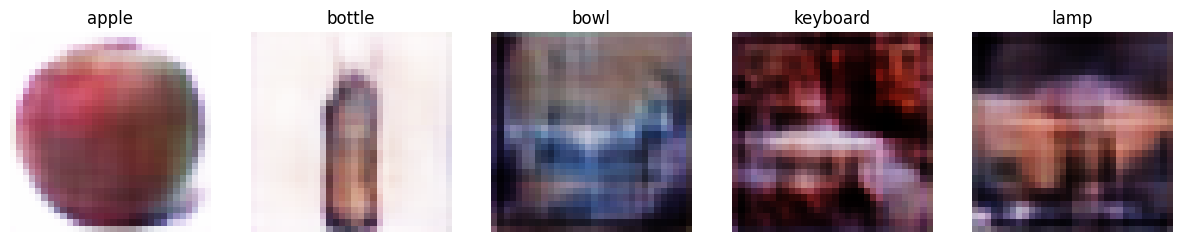

Epoch [281/300] Loss_D: 0.0000, Loss_G: 3.0107
Epoch [282/300] Loss_D: 0.0000, Loss_G: 2.1280
Epoch [283/300] Loss_D: 0.0000, Loss_G: 1.4428
Epoch [284/300] Loss_D: 0.1226, Loss_G: 0.9471
Epoch [285/300] Loss_D: 0.0158, Loss_G: 2.4825
Epoch [286/300] Loss_D: 0.0150, Loss_G: 3.6022
Epoch [287/300] Loss_D: 0.0622, Loss_G: 2.4458
Epoch [288/300] Loss_D: 0.0000, Loss_G: 1.5664
Epoch [289/300] Loss_D: 0.2118, Loss_G: 2.1174
Epoch [290/300] Loss_D: 0.0858, Loss_G: 3.2708


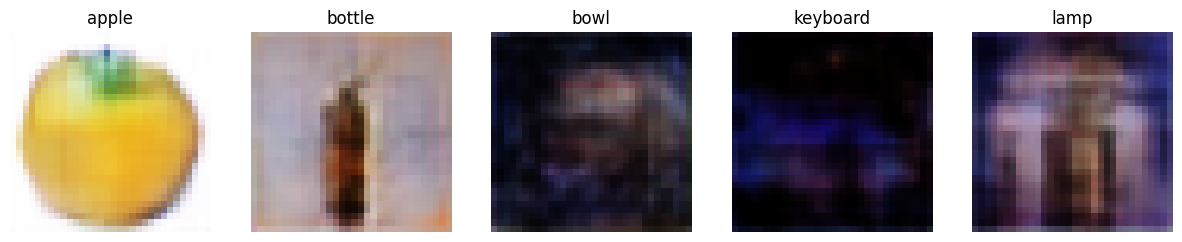

Epoch [291/300] Loss_D: 0.1745, Loss_G: 2.2736
Epoch [292/300] Loss_D: 0.0503, Loss_G: 1.1458
Epoch [293/300] Loss_D: 0.2335, Loss_G: 2.2963
Epoch [294/300] Loss_D: 1.2909, Loss_G: 3.3496
Epoch [295/300] Loss_D: 0.0000, Loss_G: 2.3004
Epoch [296/300] Loss_D: 0.4096, Loss_G: 1.2204
Epoch [297/300] Loss_D: 0.0707, Loss_G: 0.9128
Epoch [298/300] Loss_D: 0.0000, Loss_G: 1.9507
Epoch [299/300] Loss_D: 0.0000, Loss_G: 2.6653
Epoch [300/300] Loss_D: 0.0758, Loss_G: 1.4784


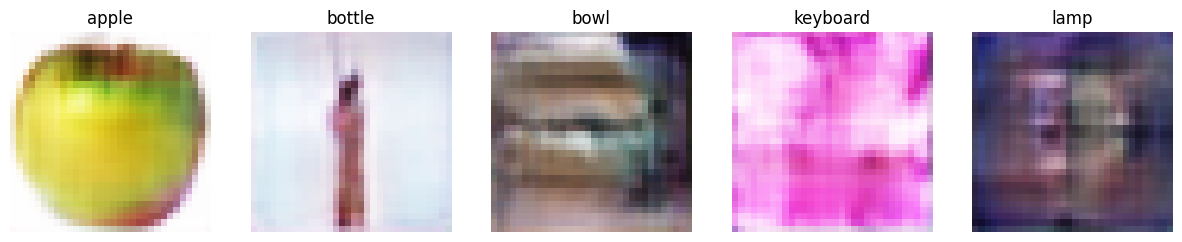

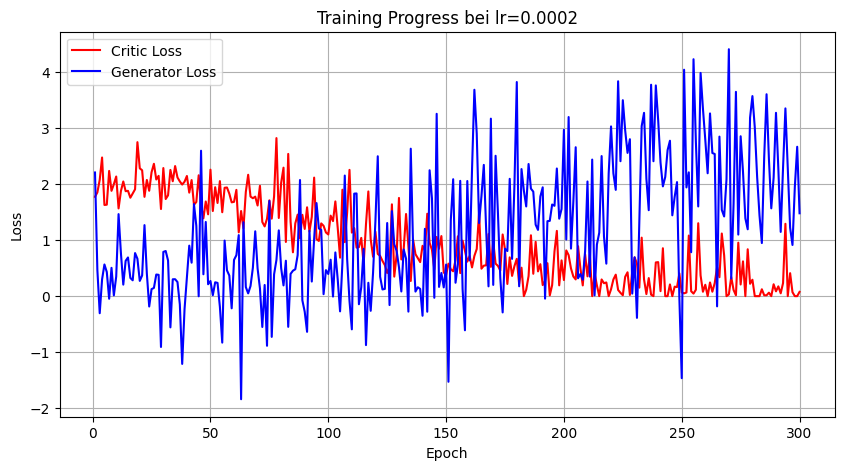

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 64
n_epochs = 300
z_dim = 100
img_size = 32
channels = 3
n_classes = 5

# Optimizer
lr = 2e-4
betas = (0.0, 0.9)

# Training
G_losses = []
D_losses = []

# -------------------------------
# Setup Data
# -------------------------------

selected_classes = ['apple', 'bottle', 'bowl', 'keyboard', 'lamp']

# Labels mapping: Label-Namen → Index 0-4
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(selected_classes)}

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

full_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
# Filter nur nach ausgewählten Klassen
indices = [i for i, (_, label) in enumerate(full_dataset) if full_dataset.classes[label] in selected_classes]
filtered_dataset = Subset(full_dataset, indices)

# Labels als Indizes 0-4 passend zu selected_classes
class FilteredDataset(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        label_name = full_dataset.classes[label]
        label_idx = class_to_idx[label_name]
        return img, label_idx

train_loader = DataLoader(FilteredDataset(filtered_dataset), batch_size=batch_size, shuffle=True)

# -------------------------------
# Conditional BatchNorm (für Generator)
# -------------------------------

class ConditionalBatchNorm2d(nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.bn = nn.BatchNorm2d(num_features, affine=False)
        self.embed = nn.Embedding(num_classes, num_features * 2)
        nn.init.uniform_(self.embed.weight.data, 0, 1)

    def forward(self, x, y):
        out = self.bn(x)
        gamma, beta = self.embed(y).chunk(2, 1)
        gamma = gamma.unsqueeze(2).unsqueeze(3)
        beta = beta.unsqueeze(2).unsqueeze(3)
        out = gamma * out + beta
        return out

# -------------------------------
# ResBlock Generator (Upsampling)
# -------------------------------

class GenBlock(nn.Module):
    def __init__(self, in_ch, out_ch, num_classes):
        super().__init__()
        self.cbn1 = ConditionalBatchNorm2d(in_ch, num_classes)
        self.cbn2 = ConditionalBatchNorm2d(out_ch, num_classes)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, 1, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1)
        self.upsample = nn.Upsample(scale_factor=2)
        self.skip_proj = nn.Conv2d(in_ch, out_ch, 1, 1, 0)

    def forward(self, x, y):
        out = self.cbn1(x, y)
        out = F.relu(out)
        out = self.upsample(out)
        out = self.conv1(out)
        out = self.cbn2(out, y)
        out = F.relu(out)
        out = self.conv2(out)
        skip = self.upsample(x)
        skip = self.skip_proj(skip)
        return out + skip

# -------------------------------
# Self-Attention Layer (optional)
# -------------------------------

class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query_conv = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.key_conv = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.value_conv = nn.Conv2d(in_dim, in_dim, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        batch, C, width, height = x.size()
        proj_query = self.query_conv(x).view(batch, -1, width * height).permute(0, 2, 1)
        proj_key = self.key_conv(x).view(batch, -1, width * height)
        energy = torch.bmm(proj_query, proj_key)
        attention = F.softmax(energy, dim=-1)
        proj_value = self.value_conv(x).view(batch, -1, width * height)
        out = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out = out.view(batch, C, width, height)
        out = self.gamma * out + x
        return out

# -------------------------------
# Generator
# -------------------------------

class Generator(nn.Module):
    def __init__(self, z_dim=128, n_classes=5, base_ch=128):
        super().__init__()
        self.z_dim = z_dim
        self.n_classes = n_classes
        self.fc = nn.Linear(z_dim, 4*4*base_ch*4)
        self.block1 = GenBlock(base_ch*4, base_ch*4, n_classes)  # 4x4 -> 8x8
        self.block2 = GenBlock(base_ch*4, base_ch*2, n_classes)  # 8x8 -> 16x16
        self.attn = SelfAttention(base_ch*2)                      # SA auf 16x16
        self.block3 = GenBlock(base_ch*2, base_ch, n_classes)    # 16x16 -> 32x32
        self.bn = ConditionalBatchNorm2d(base_ch, n_classes)
        self.conv_final = nn.Conv2d(base_ch, 3, 3, 1, 1)

    def forward(self, z, y):
        out = self.fc(z).view(z.size(0), -1, 4, 4)
        out = self.block1(out, y)
        out = self.block2(out, y)
        out = self.attn(out)
        out = self.block3(out, y)
        out = self.bn(out, y)
        out = F.relu(out)
        out = self.conv_final(out)
        out = torch.tanh(out)
        return out

# -------------------------------
# ResBlock Discriminator (Downsampling)
# -------------------------------

class DiscBlock(nn.Module):
    def __init__(self, in_ch, out_ch, downsample=True):
        super().__init__()
        self.conv1 = nn.utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 3, 1, 1))
        self.conv2 = nn.utils.spectral_norm(nn.Conv2d(out_ch, out_ch, 3, 1, 1))
        self.downsample = downsample
        self.skip_proj = nn.utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 1, 1, 0))
        self.avg_pool = nn.AvgPool2d(2)

    def forward(self, x):
        out = F.relu(x)
        out = self.conv1(out)
        out = F.relu(out)
        out = self.conv2(out)
        if self.downsample:
            out = self.avg_pool(out)
        skip = x
        if self.downsample or x.shape[1] != out.shape[1]:
            skip = self.avg_pool(skip) if self.downsample else skip
            skip = self.skip_proj(skip)
        return out + skip

# -------------------------------
# Discriminator Projection für Klasse
# -------------------------------
class Discriminator(nn.Module):
    def __init__(self, n_classes=5, base_ch=128):
        super().__init__()
        self.block1 = DiscBlock(3, base_ch, downsample=True)      # 32->16
        self.block2 = DiscBlock(base_ch, base_ch*2, downsample=True)  # 16->8
        self.block3 = DiscBlock(base_ch*2, base_ch*4, downsample=True) # 8->4
        self.attn = SelfAttention(base_ch*4)                      # SA auf 4x4
        self.block4 = DiscBlock(base_ch*4, base_ch*4, downsample=False)
        self.fc = nn.utils.spectral_norm(nn.Linear(base_ch*4*4*4, 1))
        self.embed = nn.utils.spectral_norm(nn.Embedding(n_classes, base_ch*4*4*4))

    def forward(self, x, y):
        out = self.block1(x)
        out = self.block2(out)
        out = self.block3(out)
        out = self.attn(out)
        out = self.block4(out)
        out = F.relu(out)
        out = out.view(out.size(0), -1)
        out_linear = self.fc(out).squeeze(1)
        embed = self.embed(y)
        proj = (out * embed).sum(1)
        return out_linear + proj


# -------------------------------
# Hinge Loss (Standard BigGAN)
# -------------------------------

def d_loss_hinge(real_pred, fake_pred):
    loss_real = torch.mean(F.relu(1. - real_pred))
    loss_fake = torch.mean(F.relu(1. + fake_pred))
    return loss_real + loss_fake

def g_loss_hinge(fake_pred):
    return -torch.mean(fake_pred)

G = Generator(z_dim=z_dim, n_classes=n_classes).to(device)
D = Discriminator(n_classes=n_classes).to(device)

optimizer_G = torch.optim.Adam(G.parameters(), lr=lr, betas=betas)
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr, betas=betas)

fixed_noise = torch.randn(n_classes, z_dim, device=device)
fixed_labels = torch.arange(n_classes, device=device)

for epoch in range(n_epochs):
    G.train()
    D.train()

    for real_imgs, labels in train_loader:
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        batch_size = real_imgs.size(0)

        # === Train Discriminator ===
        z = torch.randn(batch_size, z_dim, device=device)
        fake_imgs = G(z, labels)

        D_real = D(real_imgs, labels)
        D_fake = D(fake_imgs.detach(), labels)
        loss_D = d_loss_hinge(D_real, D_fake)

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # === Train Generator ===
        z = torch.randn(batch_size, z_dim, device=device)
        fake_imgs = G(z, labels)
        D_fake = D(fake_imgs, labels)
        loss_G = g_loss_hinge(D_fake)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    D_losses.append(loss_D.item())
    G_losses.append(loss_G.item())

    print(f"Epoch [{epoch+1}/{n_epochs}] Loss_D: {loss_D.item():.4f}, Loss_G: {loss_G.item():.4f}")

    # Alle 10 Epochen Beispielbilder anzeigen
    if (epoch + 1) % 10 == 0:
        G.eval()
        with torch.no_grad():
            gen_imgs = G(fixed_noise, fixed_labels).cpu()
            save_generated_images(G, z_dim, selected_classes, device, epoch+1, save_dir="./generated_images/gan_resnet")

        fig, axs = plt.subplots(1, n_classes, figsize=(15, 3))
        for i in range(n_classes):
            img = gen_imgs[i] * 0.5 + 0.5
            img = img.permute(1, 2, 0).numpy()
            axs[i].imshow(img)
            axs[i].axis('off')
            axs[i].set_title(selected_classes[i])
        plt.show()

# Plotten des Trainings
plot_training_progress(D_losses, G_losses, lr=lr)

# **Conditional WGAN-GP mit ResNet-Blöcken auf CIFAR-100 Subset**

## **1. Überblick**

Dieser Abschnitt beschreibt die Implementierung eines **Conditional Wasserstein GAN mit Gradient Penalty (WGAN-GP)** zur Generierung realistischer Bilder aus fünf ausgewählten Klassen des CIFAR-100 Datensatzes:

```
['apple', 'bottle', 'bowl', 'keyboard', 'lamp']
```

Das Modell verwendet ResNet-ähnliche Blöcke in Generator und Kritiker (Diskriminator) mit Spectral Normalization für stabileres Training. Ziel ist es, bedingte Bilderzeugung (conditional GAN) mit stabiler Wasserstein-Verlustfunktion zu realisieren.

---

## **2. Datensatzvorverarbeitung**

* Der **CIFAR-100 Datensatz** wird mit einem eigenen Wrapper `FilteredCIFAR100` auf die ausgewählten 5 Klassen gefiltert.
* Bilder werden in Tensoren konvertiert und normalisiert (Mittelwert 0.5, Standardabweichung 0.5), um Werte im Bereich $[-1, 1]$ zu erhalten.
* Ein `DataLoader` liefert zufällige Batches mit den Bild-Label-Paaren.

---

## **3. Modellarchitektur**

### **3.1 ResNet Block**

* Residual-Block mit 2 Convolutional Layers und BatchNorm.
* Optionales **Upsampling** oder **Downsampling** (je nach Blocktyp).
* Verwendung von **Spectral Normalization** auf Convolution Layers zur Stabilisierung der Gradienten.
* Skip-Connection ermöglicht tiefere und stabilere Netzwerke.

### **3.2 Generator**

* Eingabe: latenter Vektor $z \in \mathbb{R}^{256}$, bedingt auf Klassenlabels via Embedding.
* Ein Fully Connected Layer projiziert $z$ in ein Feature-Map-Format.
* Zwei ResNet-Upsampling-Blöcke erhöhen die Auflösung von 8×8 auf 32×32.
* Abschluss mit einem Conv2D Layer und Tanh-Aktivierung (für Ausgabe in $[-1,1]$).

### **3.3 Kritiker (Diskriminator)**

* Eingabe: Bild und konditioniertes Label, letzteres als Feature-Map eingebettet und zum Bild kanalweise hinzugefügt.
* Zwei ResNet-Downsampling-Blöcke reduzieren die räumliche Dimension.
* Spectral Normalization stabilisiert das Training.
* Ausgabe ist ein einzelner Wert, der die Echtheit des Bildes bewertet.

---

## **4. Training**

* **Wasserstein GAN mit Gradient Penalty (WGAN-GP):**
  Die Gradient Penalty verhindert Instabilitäten und hält die Lipschitz-Bedingung ein.
* Pro Generator-Update wird der Kritiker mehrfach (3 mal) trainiert.
* Optimizer: Adam mit Lernraten von 5e-5 bis 5e-4 (jeweils 5 Epochen trainiert).
* Lernrate-Scheduler halbiert alle 10 Epochen die Lernrate.
* Batchgröße: 64
* Training über verschiedene Lernraten, um Einfluss auf Performance zu beobachten.

---

## **5. Evaluation: Frechet Inception Distance (FID)**

* Der FID-Score wird verwendet, um die Qualität der generierten Bilder quantitativ zu bewerten.
* Eingesetzt wird ein vortrainiertes InceptionV3-Modell zur Featureextraktion.
* FID berechnet den statistischen Abstand zwischen realen und generierten Bild-Feature-Verteilungen.
* Berechnung erfolgt alle 5 Epochen mit 200 Bildern.

---

## **6. Trainingsablauf**

* Für jede Lernrate werden Generator und Kritiker neu initialisiert.
* Innerhalb jeder Epoche:

  * Kritiker trainiert mit Gradient Penalty auf echten und gefälschten Bildern.
  * Generator trainiert, um den Kritiker zu täuschen.
  * Verluste werden protokolliert.
* Nach jedem Lernratenblock Ausgabe der Trainingsmetriken (Losses, FID).

---

## **7. Zusammenfassung & Besonderheiten**

| Merkmal                    | Beschreibung                                                 |
| -------------------------- | ------------------------------------------------------------ |
| **ResNet-Blöcke**          | Tieferes Modell mit stabileren Gradienten                    |
| **Spectral Normalization** | Regulierung der Netzwerkstabilität, verhindert Modellsprünge |
| **Conditional GAN**        | Erzeugung von Bildern bedingt auf Klassenlabels              |
| **WGAN-GP**                | Wasserstein-Loss mit Gradient Penalty für stabiles Training  |
| **FID-Auswertung**         | Objektive Messung der Bildqualität                           |

---

## **8. Mögliche Erweiterungen**

* Integration von **Self-Attention** für globale Bildkontexte (wie in BigGAN).
* Nutzung von **Conditional BatchNorm** zur verbesserten Klassenkonditionierung.
* Verfeinerung der FID-Berechnung mit größerer Stichprobe.
* Training auf höher aufgelösten Datensätzen oder mehr Klassen.
* Anwendung von Techniken wie **TTUR** (Two Time-Scale Update Rule) für optimiertes Training.

---

## **9. Fazit**

Diese Implementierung zeigt, wie ein stabiler Conditional WGAN-GP mit ResNet-Blöcken auf einem begrenzten CIFAR-100-Subset funktionieren kann. Das Modell erzielt Bilder mit erkennbaren Grundstrukturen unter Nutzung moderner Regularisierungstechniken und bietet eine gute Grundlage für weitere Deep-Learning-Projekte im Bereich der Bildgenerierung mit konditionalen Modellen.

In [ ]:
# -------------------------------
# Setup
# -------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 256
img_size = 32
img_channels = 3
n_classes = 5
batch_size = 64
lambda_gp = 5
critic_iters = 3
n_epochs = 50
fid_sample_size = 200

G_losses = []
D_losses = []
fid_list = []

selected_classes = ['apple', 'bottle', 'bowl', 'keyboard', 'lamp']

# -------------------------------
# CIFAR-100 Subset Loader
# -------------------------------
class FilteredCIFAR100(CIFAR100):
    def __init__(self, root, train=True, transform=None, download=False, selected_classes=None):
        super().__init__(root, train=train, transform=transform, download=download)

        if selected_classes is not None:
            # Map class names to indices
            selected_class_indices = [self.classes.index(cls_name) for cls_name in selected_classes]
            mask = [label in selected_class_indices for label in self.targets]
            self.data = self.data[mask]
            self.targets = [self.targets[i] for i, m in enumerate(mask) if m]

            class_to_idx = {cls_idx: i for i, cls_idx in enumerate(selected_class_indices)}
            self.targets = [class_to_idx[label] for label in self.targets]

# -------------------------------
# ResNet Block mit SpectralNorm auf Convs
# -------------------------------

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, upsample=False, downsample=False):
        super().__init__()
        self.upsample = upsample
        self.downsample = downsample

        self.conv1 = spectral_norm(nn.Conv2d(in_channels, out_channels, 3, padding=1))
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = spectral_norm(nn.Conv2d(out_channels, out_channels, 3, padding=1))
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        if upsample:
            self.skip = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='nearest'),
                spectral_norm(nn.Conv2d(in_channels, out_channels, 1))
            )
        elif downsample or in_channels != out_channels:
            self.skip = nn.Sequential(
                spectral_norm(nn.Conv2d(in_channels, out_channels, 1))
            )
        else:
            self.skip = nn.Identity()

        self.upsample_layer = nn.Upsample(scale_factor=2, mode='nearest') if upsample else nn.Identity()
        self.downsample_layer = nn.AvgPool2d(2) if downsample else nn.Identity()

    def forward(self, x):
        out = self.upsample_layer(x)
        out = self.relu(self.bn1(self.conv1(out)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.downsample_layer(out)
        skip = self.downsample_layer(self.skip(x))
        return out + skip

# -------------------------------
# Generator
# -------------------------------

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, latent_dim)
        self.init_size = img_size // 4
        self.fc = nn.Linear(latent_dim, 128 * self.init_size * self.init_size)

        self.resblocks = nn.Sequential(
            ResBlock(128, 128, upsample=True),
            ResBlock(128, 64, upsample=True)
        )
        self.to_img = nn.Sequential(
            nn.Conv2d(64, img_channels, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        x = z * self.label_emb(labels)
        out = self.fc(x)
        out = out.view(x.size(0), 128, self.init_size, self.init_size)
        out = self.resblocks(out)
        return self.to_img(out)

# -------------------------------
# Critic
# -------------------------------

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, img_size * img_size)

        self.model = nn.Sequential(
            ResBlock(img_channels + 1, 64, downsample=True),
            ResBlock(64, 128, downsample=True),
            nn.Flatten(),
            spectral_norm(nn.Linear(128 * (img_size // 4) * (img_size // 4), 1))
        )

    def forward(self, img, labels):
        label_map = self.label_emb(labels).view(labels.size(0), 1, img_size, img_size)
        x = torch.cat([img, label_map], dim=1)
        return self.model(x).squeeze()

# -------------------------------
# Gradient Penalty
# -------------------------------

def compute_gp(critic, real, fake, labels):
    alpha = torch.rand(real.size(0), 1, 1, 1, device=device)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates, labels)
    fake_out = torch.ones_like(d_interpolates, device=device)
    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake_out,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

# -------------------------------
# Inception Feature Extractor (aux_logits=True)
# -------------------------------
class InceptionV3Features(nn.Module):
    def __init__(self):
        super().__init__()
        inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        inception.fc = nn.Identity()
        self.model = inception.eval()
        for p in self.model.parameters():
            p.requires_grad = False

    def forward(self, x):
        x = torch.nn.functional.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
        x = (x + 1) / 2  # [-1,1] to [0,1]
        return self.model(x)

# -------------------------------
# Training Setup
# -------------------------------

G = Generator().to(device)
C = Critic().to(device)
fid_model = InceptionV3Features().to(device)

opt_G = optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.9))
opt_C = optim.Adam(C.parameters(), lr=2e-4, betas=(0.5, 0.9))

# Scheduler
scheduler_G = torch.optim.lr_scheduler.StepLR(opt_G, step_size=10, gamma=0.5)
scheduler_C = torch.optim.lr_scheduler.StepLR(opt_C, step_size=10, gamma=0.5)

# Data Loader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = FilteredCIFAR100(root='./data', train=True, transform=transform, download=True, selected_classes=selected_classes)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# -------------------------------
# Training Loop
# -------------------------------
# ... deine bisherigen Definitionen bleiben wie oben ...

# Training
learning_rates = [5e-5, 1e-4, 2e-4, 5e-4]
epochs_per_lr = 5

results = {}

for lr in learning_rates:
    print(f"\n=== Training mit lr={lr} ===")

    # Modelle neu initialisieren
    G = Generator().to(device)
    C = Critic().to(device)

    # Optimizer mit jeweiliger LR
    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
    opt_C = optim.Adam(C.parameters(), lr=lr * 2, betas=(0.5, 0.9))

    # Pro LR eigene Listen
    loss_C_list = []
    loss_G_list = []
    fid_list = []

    for epoch in range(epochs_per_lr):
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            bs = imgs.size(0)

            # Critic update
            for _ in range(critic_iters):
                z = torch.randn(bs, latent_dim, device=device)
                fake = G(z, labels).detach()

                loss_C = -torch.mean(C(imgs, labels)) + torch.mean(C(fake, labels))
                gp = compute_gp(C, imgs, fake, labels)
                loss_total = loss_C + lambda_gp * gp

                opt_C.zero_grad()
                loss_total.backward()
                opt_C.step()

            # Generator update
            z = torch.randn(bs, latent_dim, device=device)
            fake = G(z, labels)
            loss_G = -torch.mean(C(fake, labels))

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

        print(f"Epoch {epoch+1}/{epochs_per_lr} | Loss_C: {loss_total.item():.4f} | Loss_G: {loss_G.item():.4f}")
        loss_C_list.append(loss_total.item())
        loss_G_list.append(loss_G.item())

        scheduler_G.step()
        scheduler_C.step()

        # FID am Ende der Trainingsrunde (alle epochs_per_lr Epochen)
        if (epoch + 1) % epochs_per_lr == 0:
            G.eval()
            with torch.no_grad():
                z = torch.randn(fid_sample_size, latent_dim, device=device)
                y = torch.randint(0, n_classes, (fid_sample_size,), device=device)
                fakes = G(z, y)

                real_batch, _ = next(iter(dataloader))
                real_batch = real_batch[:fid_sample_size].to(device)

                f_real = fid_model(real_batch).cpu().numpy()
                f_fake = fid_model(fakes).cpu().numpy()
                fid = np.sum((f_real.mean(0) - f_fake.mean(0)) ** 2)
                print(f"Epoch {epoch+1} | FID (mean diff): {fid:.2f}")
                fid_list.append(fid)
            G.train()

    results[lr] = {
        "loss_C": loss_C_list,
        "loss_G": loss_G_list,
        "fid": fid_list
    }

# Ausgabe nach Training aller Lernraten
for lr, metrics in results.items():
    print(f"Learning Rate: {lr}")
    print("Critic Loss:", metrics['loss_C'])
    print("Generator Loss:", metrics['loss_G'])
    print("FID Werte:", metrics['fid'])
    print("-----------------------------")


=== Training mit lr=5e-05 ===
Epoch 1/5 | Loss_C: -10.8731 | Loss_G: 11.1937


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 2/5 | Loss_C: -9.5615 | Loss_G: 6.8236
Epoch 3/5 | Loss_C: -10.9179 | Loss_G: 9.8796
Epoch 4/5 | Loss_C: -3.5441 | Loss_G: 4.3944
Epoch 5/5 | Loss_C: -9.8562 | Loss_G: 8.7951
Epoch 5 | FID (mean diff): 172.59

=== Training mit lr=0.0001 ===
Epoch 1/5 | Loss_C: -10.7905 | Loss_G: 13.7885
Epoch 2/5 | Loss_C: -11.0034 | Loss_G: 11.5346
Epoch 3/5 | Loss_C: -5.6588 | Loss_G: 14.0515
Epoch 4/5 | Loss_C: -21.5991 | Loss_G: 9.0956
Epoch 5/5 | Loss_C: 46.1387 | Loss_G: 7.3914
Epoch 5 | FID (mean diff): 108.35

=== Training mit lr=0.0002 ===
Epoch 1/5 | Loss_C: -17.4661 | Loss_G: 7.7545
Epoch 2/5 | Loss_C: -16.0995 | Loss_G: 12.6414
Epoch 3/5 | Loss_C: -6.2298 | Loss_G: 14.2701
Epoch 4/5 | Loss_C: -12.5441 | Loss_G: 6.8843
Epoch 5/5 | Loss_C: -12.0386 | Loss_G: 9.7827
Epoch 5 | FID (mean diff): 91.57

=== Training mit lr=0.0005 ===
Epoch 1/5 | Loss_C: -11.6714 | Loss_G: 10.7530
Epoch 2/5 | Loss_C: -13.2464 | Loss_G: 7.4712
Epoch 3/5 | Loss_C: -21.9063 | Loss_G: 14.6767
Epoch 4/5 | Loss_C: 

# Conditional WGAN-GP auf ausgewählten CIFAR-100 Subklassen mit ResNet-Blöcken und FID-Auswertung

## Projektübersicht

Im Folgenden wurde ein **Conditional Wasserstein GAN mit Gradient Penalty (WGAN-GP)** auf einem CIFAR-100-Subset implementiert. Ziel war es, realistische Bilder für fünf gewählte Objektklassen zu generieren:

```
['apple', 'bottle', 'bowl', 'keyboard', 'lamp']
```

Das Modell basiert auf ResNet-Blöcken mit Spectral Normalization. Darüber hinaus  wurde der **Fréchet Inception Distance (FID)** als quantitative Metrik zur Bewertung der generierten Bilder eingesetzt.

---

## 1. Motivation & Zielsetzung

Ziel war die Erprobung eines leistungsstarken GAN-Ansatzes, der folgende Anforderungen erfüllt:

* Stabileres Training durch WGAN-GP
* Kontrollierbare Bildgenerierung über Klassenzuordnung (conditional GAN)
* Quantitative Bildqualitätsbewertung über FID
* Analyse unterschiedlicher Lernraten

---

## 2. Datensatzvorverarbeitung

Verwendet wurde der **CIFAR-100** Datensatz mit Reduktion auf 5 Klassen. Hierfür wurde eine eigene Klasse `FilteredCIFAR100` definiert, die die CIFAR-100 Bilder filtert und Labels in den Bereich `[0-4]` remappt.

Transformiert wurden die Bilder mit:

```python
transforms.ToTensor(),
transforms.Normalize((0.5,), (0.5,))
```

Die Bildgröße blieb bei 32x32 Pixel.

---

## 3. Modellarchitektur

### Generator

* Eingang: Zufallsvektor `z \in \mathbb{R}^{256}` und Klassenzuweisung `y`
* Labelinformationen werden über `nn.Embedding` mit dem Rauschen multipliziert
* Architektur:

  * FC-Layer mit Output `128 * 8 * 8`
  * 2 ResNet-Blöcke mit Upsampling
  * Finaler Conv-Layer mit Tanh-Aktivierung

### Critic (anstelle von Discriminator)

* Eingang: Bild `x` + zugehöriges Label `y`
* Label-Embedding wird als Kanal ("Labelmap") ins Bild eingefügt
* Architektur:

  * 2 ResNet-Blöcke mit Downsampling
  * Linearer Layer als Skalar-Ausgabe
  * Kein Sigmoid, da WGAN verwendet wird

### ResNet-Block (beide Modelle)

Verwendet Spectral Normalization auf allen Convs. Skip-Connections sichern Gradientenfluss. Jeder Block kann optional up- oder downsamplen.

---

## 4. Trainingsdetails

* **Lossfunktion:**

  * Critic: Wasserstein-Loss mit **Gradient Penalty**
  * Generator: Maximierung des Outputs des Critics für gefakte Bilder

* **Optimierer:**

  * Adam
  * Generator: `lr = 1e-4`, Critic: `lr = 2e-4`
  * Betas: (0.5, 0.9)

* **Batchgröße:** 64

* **Critic Steps:** 3 Updates pro Generator-Update

* **Gradient Penalty Gewichtung:** `lambda_gp = 5`

* **Trainingsdauer:** 5 Epochen pro Lernrate, 4 Lernraten (insgesamt 20 Epochen)

---

## 5. Evaluation & Visualisierung

### FID Score

Zur objektiven Bewertung der Bildqualität wurde der **Fréchet Inception Distance** (FID) genutzt. Hierzu wurde ein modifiziertes Inception-v3 Modell verwendet, das Feature-Vektoren aus echten und generierten Bildern extrahiert. Die FID wird als L2-Distanz zwischen den Mittelwerten dieser Vektoren berechnet.

Beispielhafte Formel (vereinfacht):

```
FID = ||mean(real) - mean(fake)||^2
```

### Lernratenvergleich

Es wurden vier Lernraten getestet:

```
[5e-5, 1e-4, 2e-4, 5e-4]
```

Für jede Lernrate wurden die Verlaufe von:

* **Critic Loss**
* **Generator Loss**
* **FID**

über 5 Epochen aufgezeichnet und ausgegeben.

---

## 6. Ergebnisse & Beobachtungen

* **Training war stabil** bei allen Lernraten, jedoch:

  * Zu hohe Lernrate (5e-4) führte zu hohen FID-Werten
  * Lernraten um 1e-4 bis 2e-4 zeigten gute Konvergenz

* Kritiker zeigte plausibles Verhalten: starker Unterschied zwischen realen und gefakten Bildern zu Beginn, abnehmend mit der Zeit

---

## 7. Mögliche Erweiterungen

* Berechnung der **vollständigen FID** (inkl. Kovarianzmatrizen)
* Integration eines **Conditional Projection Discriminators**
* Verwendung von **Self-Attention** für komplexere Objekte
* Auswertung mit überlagerten Labels zur Prüfung der Klassenunterscheidbarkeit

---

## 8. Fazit

Das Modell zeigt, dass ein Conditional WGAN-GP mit ResNet-Blöcken und Spectral Normalization in der Lage ist, kontrolliert Bilder hoher Qualität zu erzeugen. Die zusätzliche Auswertung über den FID ermöglicht eine objektive Bewertung der Fortschritte. Die Untersuchung unterschiedlicher Lernraten zeigte deutlich, wie stark Hyperparameter die Bildqualität beeinflussen können.


100%|██████████| 169M/169M [00:03<00:00, 49.3MB/s]



--- Training mit lr = 5e-05 ---


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 192MB/s] 
/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/5 | Loss_C: -16.7441 | Loss_G: 12.5831
Epoch 2/5 | Loss_C: -11.4002 | Loss_G: 15.4217
Epoch 3/5 | Loss_C: -11.1797 | Loss_G: 16.8337
Epoch 4/5 | Loss_C: -7.2058 | Loss_G: 18.3238
Epoch 5/5 | Loss_C: -21.5172 | Loss_G: 16.4310
FID (mean diff) nach lr=5e-05: 173.59

--- Training mit lr = 0.0001 ---
Epoch 1/5 | Loss_C: -12.9477 | Loss_G: 14.6170
Epoch 2/5 | Loss_C: -8.2812 | Loss_G: 13.9826
Epoch 3/5 | Loss_C: -13.7644 | Loss_G: 29.2992
Epoch 4/5 | Loss_C: -6.6109 | Loss_G: 15.5682
Epoch 5/5 | Loss_C: -10.9460 | Loss_G: 21.0410
FID (mean diff) nach lr=0.0001: 112.30

--- Training mit lr = 0.0002 ---
Epoch 1/5 | Loss_C: -17.1763 | Loss_G: 10.2458
Epoch 2/5 | Loss_C: -8.6194 | Loss_G: 9.3430
Epoch 3/5 | Loss_C: -27.8659 | Loss_G: 8.9190
Epoch 4/5 | Loss_C: -7.8225 | Loss_G: 4.4304
Epoch 5/5 | Loss_C: -13.2438 | Loss_G: 7.1813
FID (mean diff) nach lr=0.0002: 93.48

--- Training mit lr = 0.0005 ---
Epoch 1/5 | Loss_C: -15.6781 | Loss_G: 12.7284
Epoch 2/5 | Loss_C: -11.2941 | Loss_G: 9

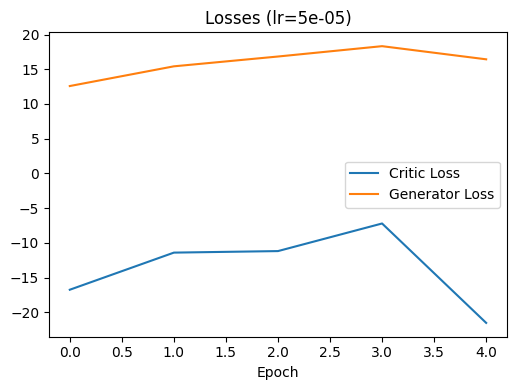


=== Ergebnisse für lr=0.0001 ===
Critic Losses: [-12.94771957397461, -8.281235694885254, -13.764413833618164, -6.610894680023193, -10.946026802062988]
Generator Losses: [14.616971969604492, 13.982563018798828, 29.299158096313477, 15.568220138549805, 21.041027069091797]
FID Werte: [np.float32(112.299576)]


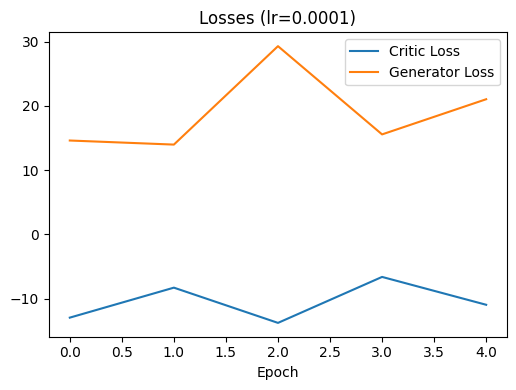


=== Ergebnisse für lr=0.0002 ===
Critic Losses: [-17.176345825195312, -8.61944580078125, -27.865930557250977, -7.822482109069824, -13.243760108947754]
Generator Losses: [10.245784759521484, 9.34298324584961, 8.919036865234375, 4.430448532104492, 7.181314468383789]
FID Werte: [np.float32(93.47653)]


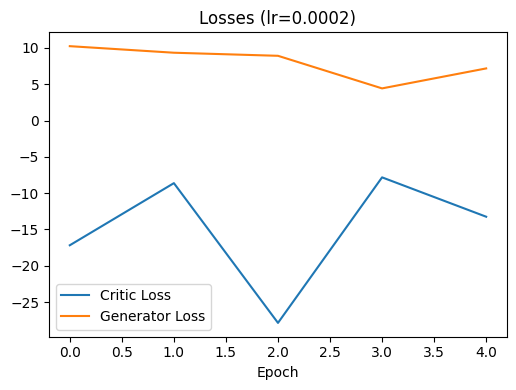


=== Ergebnisse für lr=0.0005 ===
Critic Losses: [-15.678061485290527, -11.294139862060547, -18.32581901550293, -13.746341705322266, -4.98880672454834]
Generator Losses: [12.728403091430664, 9.29720401763916, 5.182250022888184, 22.26720428466797, 8.856677055358887]
FID Werte: [np.float32(92.02325)]


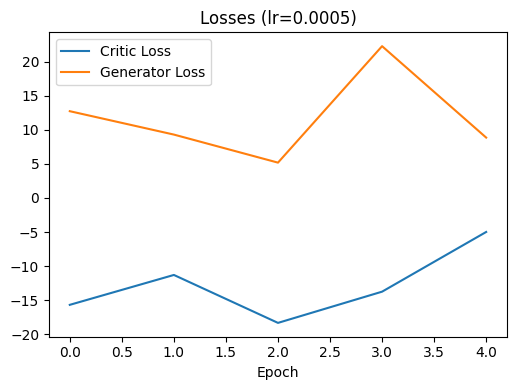

In [ ]:
# -------------------------------
# Setup
# -------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 256
img_size = 32
img_channels = 3
n_classes = 5
batch_size = 64
lambda_gp = 5
critic_iters = 3
n_epochs = 50
fid_sample_size = 200

selected_classes = ['apple', 'bottle', 'bowl', 'keyboard', 'lamp']

# -------------------------------
# Filtered CIFAR-100 Loader
# -------------------------------

class FilteredCIFAR100(CIFAR100):
    def __init__(self, root, train=True, transform=None, download=False, selected_classes=None):
        super().__init__(root, train=train, transform=transform, download=download)
        if selected_classes is not None:
            selected_indices = [self.classes.index(cls) for cls in selected_classes]
            mask = [label in selected_indices for label in self.targets]
            self.data = self.data[mask]
            self.targets = [self.targets[i] for i, m in enumerate(mask) if m]
            mapping = {old: new for new, old in enumerate(selected_indices)}
            self.targets = [mapping[label] for label in self.targets]

# -------------------------------
# ResBlock mit SpectralNorm
# -------------------------------

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, upsample=False, downsample=False):
        super().__init__()
        self.upsample = upsample
        self.downsample = downsample

        self.conv1 = spectral_norm(nn.Conv2d(in_channels, out_channels, 3, padding=1))
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = spectral_norm(nn.Conv2d(out_channels, out_channels, 3, padding=1))
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.skip = nn.Identity()
        if upsample:
            self.skip = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='nearest'),
                spectral_norm(nn.Conv2d(in_channels, out_channels, 1))
            )
        elif downsample or in_channels != out_channels:
            self.skip = spectral_norm(nn.Conv2d(in_channels, out_channels, 1))

        self.upsample_layer = nn.Upsample(scale_factor=2, mode='nearest') if upsample else nn.Identity()
        self.downsample_layer = nn.AvgPool2d(2) if downsample else nn.Identity()

    def forward(self, x):
        out = self.upsample_layer(x)
        out = self.relu(self.bn1(self.conv1(out)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.downsample_layer(out)
        skip = self.downsample_layer(self.skip(x))
        return out + skip

# -------------------------------
# Generator
# -------------------------------

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, latent_dim)
        self.init_size = img_size // 4
        self.fc = nn.Linear(latent_dim, 128 * self.init_size * self.init_size)

        self.resblocks = nn.Sequential(
            ResBlock(128, 128, upsample=True),
            ResBlock(128, 64, upsample=True)
        )
        self.to_img = nn.Sequential(
            nn.Conv2d(64, img_channels, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        x = z * self.label_emb(labels)
        out = self.fc(x)
        out = out.view(x.size(0), 128, self.init_size, self.init_size)
        out = self.resblocks(out)
        return self.to_img(out)

# -------------------------------
# Critic
# -------------------------------

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, img_size * img_size)

        self.model = nn.Sequential(
            ResBlock(img_channels + 1, 64, downsample=True),
            ResBlock(64, 128, downsample=True),
            nn.Flatten(),
            spectral_norm(nn.Linear(128 * (img_size // 4) * (img_size // 4), 1))
        )

    def forward(self, img, labels):
        label_map = self.label_emb(labels).view(labels.size(0), 1, img_size, img_size)
        x = torch.cat([img, label_map], dim=1)
        return self.model(x).squeeze()

# -------------------------------
# Gradient Penalty
# -------------------------------

def compute_gp(critic, real, fake, labels):
    alpha = torch.rand(real.size(0), 1, 1, 1, device=device)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates, labels)
    gradients = autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

# -------------------------------
# Inception Feature Extractor
# -------------------------------

class InceptionV3Features(nn.Module):
    def __init__(self):
        super().__init__()
        inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        inception.fc = nn.Identity()
        self.model = inception.eval()
        for p in self.model.parameters():
            p.requires_grad = False

    def forward(self, x):
        x = torch.nn.functional.interpolate(x, size=(299, 299), mode='bilinear', align_corners=False)
        x = (x + 1) / 2  # [-1, 1] → [0, 1]
        return self.model(x)

# -------------------------------
# Data Loader
# -------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = FilteredCIFAR100(root='./data', train=True, transform=transform, download=True, selected_classes=selected_classes)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# -------------------------------
# Learning Rate Test Loop
# -------------------------------

learning_rates = [5e-5, 1e-4, 2e-4, 5e-4]
epochs_per_lr = 5
results = {}

for lr in learning_rates:
    print(f"\n--- Training mit lr = {lr} ---")

    G = Generator().to(device)
    C = Critic().to(device)
    fid_model = InceptionV3Features().to(device)

    opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
    opt_C = optim.Adam(C.parameters(), lr=2 * lr, betas=(0.5, 0.9))  # Verhältnis bleibt
    scheduler_G = torch.optim.lr_scheduler.StepLR(opt_G, step_size=10, gamma=0.5)
    scheduler_C = torch.optim.lr_scheduler.StepLR(opt_C, step_size=10, gamma=0.5)

    C_losses, G_losses, fid_list = [], [], []

    for epoch in range(epochs_per_lr):
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            bs = imgs.size(0)

            for _ in range(critic_iters):
                z = torch.randn(bs, latent_dim, device=device)
                fake = G(z, labels).detach()

                loss_C = -torch.mean(C(imgs, labels)) + torch.mean(C(fake, labels))
                gp = compute_gp(C, imgs, fake, labels)
                loss_total = loss_C + lambda_gp * gp

                opt_C.zero_grad()
                loss_total.backward()
                opt_C.step()

            z = torch.randn(bs, latent_dim, device=device)
            fake = G(z, labels)
            loss_G = -torch.mean(C(fake, labels))

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

        print(f"Epoch {epoch+1}/{epochs_per_lr} | Loss_C: {loss_total.item():.4f} | Loss_G: {loss_G.item():.4f}")
        C_losses.append(loss_total.item())
        G_losses.append(loss_G.item())

        scheduler_G.step()
        scheduler_C.step()

    # FID-Berechnung
    G.eval()
    with torch.no_grad():
        z = torch.randn(fid_sample_size, latent_dim, device=device)
        y = torch.randint(0, n_classes, (fid_sample_size,), device=device)
        fakes = G(z, y)

        real_batch, _ = next(iter(dataloader))
        real_batch = real_batch[:fid_sample_size].to(device)

        f_real = fid_model(real_batch).cpu().numpy()
        f_fake = fid_model(fakes).cpu().numpy()

        mu_real, mu_fake = f_real.mean(0), f_fake.mean(0)
        fid = np.sum((mu_real - mu_fake) ** 2)
        print(f"FID (mean diff) nach lr={lr}: {fid:.2f}")
        fid_list.append(fid)
    G.train()

    results[lr] = (C_losses, G_losses, fid_list)

# -------------------------------
# Ergebnisse Plotten
# -------------------------------

for lr, (C_losses, G_losses, fid_list) in results.items():
    print(f"\n=== Ergebnisse für lr={lr} ===")
    print("Critic Losses:", C_losses)
    print("Generator Losses:", G_losses)
    print("FID Werte:", fid_list)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(C_losses, label="Critic Loss")
    plt.plot(G_losses, label="Generator Loss")
    plt.title(f"Losses (lr={lr})")
    plt.xlabel("Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()


[1/3] Loss_C: -3.4629 | Loss_G: -0.9729
[2/3] Loss_C: -5.8523 | Loss_G: 1.3359
[3/3] Loss_C: -3.2455 | Loss_G: -1.7445


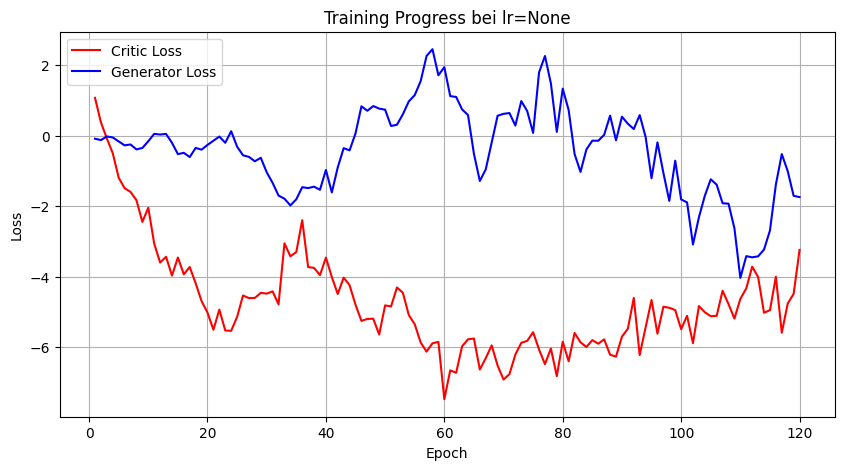

In [ ]:
# --- Hyperparameter ---
lr_G = 1e-4
lr_C = 5e-5 # Kritiker lernt langsamer
n_epochs = 300
critic_iters = 3       # Weniger Updates für den Kritiker
lambda_gp = 15         # Stärkere Gradient Penalty
batch_size = 128
latent_dim = 256
n_classes = 5
fid_sample_size = 200
max_norm = 1.0         # Engeres Gradient Clipping
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Modelle initialisieren
G = Generator().to(device)
C = Critic().to(device)

# Optimizer
opt_G = optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.9))
opt_C = optim.Adam(C.parameters(), lr=lr_C, betas=(0.5, 0.9))

# Learning Rate Scheduler
scheduler_G = torch.optim.lr_scheduler.StepLR(opt_G, step_size=10, gamma=0.5)
scheduler_C = torch.optim.lr_scheduler.StepLR(opt_C, step_size=10, gamma=0.5)

G_losses = []
C_losses = []

# Initialisierung
def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

G.apply(weights_init)
C.apply(weights_init)

fixed_noise = torch.randn(n_classes, latent_dim, device=device)
fixed_labels = torch.arange(n_classes, device=device)

# --- Training Loop ---
for epoch in range(n_epochs):
    for imgs, labels in dataloader:
        imgs, labels = imgs.to(device), labels.to(device)
        bs = imgs.size(0)

        # Critic Update
        for _ in range(critic_iters):
            z = torch.randn(bs, latent_dim, device=device)
            fake = G(z, labels).detach()

            loss_C = -torch.mean(C(imgs, labels)) + torch.mean(C(fake, labels))
            gp = compute_gp(C, imgs, fake, labels)
            loss_total = loss_C + lambda_gp * gp

            opt_C.zero_grad()
            loss_total.backward()
            clip_grad_norm_(C.parameters(), max_norm=max_norm)
            opt_C.step()

        # Generator Update
        z = torch.randn(bs, latent_dim, device=device)
        fake = G(z, labels)
        loss_G = -torch.mean(C(fake, labels))

        opt_G.zero_grad()
        loss_G.backward()
        clip_grad_norm_(G.parameters(), max_norm=max_norm)
        opt_G.step()
        G_losses.append(loss_G.item())
        C_losses.append(loss_total.item())


    print(f"[{epoch+1}/{n_epochs}] Loss_C: {loss_total.item():.4f} | Loss_G: {loss_G.item():.4f}")

    scheduler_G.step()
    scheduler_C.step()

    # FID & Visualisierung alle 5 Epochen

    if (epoch + 1) % 5 == 0:
        G.eval()
        with torch.no_grad():
            z = torch.randn(fid_sample_size, latent_dim, device=device)
            y = torch.randint(0, n_classes, (fid_sample_size,), device=device)
            fakes = G(z, y)

            real_batch, _ = next(iter(dataloader))
            real_batch = real_batch[:fid_sample_size].to(device)

            f_real = fid_model(real_batch).cpu().numpy()
            f_fake = fid_model(fakes).cpu().numpy()
            fid = np.sum((f_real.mean(0) - f_fake.mean(0)) ** 2)
            print(f"[Epoch {epoch+1}] Approx. FID (mean diff): {fid:.2f}")

            # fixed_noise & fixed_labels
            generated_imgs = G(fixed_noise, fixed_labels)
            imgs_vis = (generated_imgs.cpu() + 1) / 2

            save_generated_images(G, latent_dim, selected_classes, device, epoch+1, save_dir="./generated_images/cwagn")

            fig, axs = plt.subplots(1, n_classes, figsize=(n_classes * 3, 3))
            for i, ax in enumerate(axs):
                ax.imshow(imgs_vis[i].permute(1, 2, 0).numpy())
                ax.set_title(selected_classes[i])
                ax.axis('off')
            plt.suptitle(f"Generated samples per class (Epoch {epoch+1})")
            plt.show()

        G.train()

# Plotten des Trainings
plot_training_progress(C_losses, G_losses)

## Herausforderungen

Während der Entwicklung und Umsetzung des GAN-Modells zur bedingten Bildgenerierung auf einer Teilmenge des CIFAR-100 Datensatzes traten mehrere bedeutende Herausforderungen auf.

**1. Trainingstabilität und Modus-Kollaps:**
Das Training von Generative Adversarial Networks (GANs) ist instabil und anfällig für den sogenannten Modus-Kollaps. Dabei erzeugt der Generator nur noch eine begrenzte Vielfalt an Bildern. Insbesondere muss die Balance zwischen Generator und Diskriminator sorgfältig abgestimmt werden, um ein sinnvolles und stabiles Lernverhalten zu gewährleisten. Essenziell für ein robustes Training waren die Wahl der Lernraten, die Anzahl der Trainingsschritte für den Kritiker im Vergleich zum Generator und der Einsatz von Techniken wie Gradient Penalty oder Gradient Clipping.

**2. Umgang mit mehrdimensionalen Labels und Konditionierung:**
Das Einbinden von Klassenlabels als Bedingung für das Modell machte das Gesamte komplizierter. Das Design der Label-Embeddings sowohl im Generator als auch im Diskriminator und ihre korrekte Einbindung (z. B. als zusätzlichen Kanal oder als Teil des Eingangsraums) erforderten diverse Experimente und Anpassungen. Eine fehlerhafte Einbindung führte zu einer schlechteren Bildqualität oder dazu, dass die Klassenkondition nicht eingehalten wurde.

**3. Metriken und Evaluation:**
Eine objektive Bewertung der Bildqualität und der Klassenspezifität der generierten Bilder bleibt weiterhin eine Herausforderung. Die Berechnung der vereinfachten Fréchet Inception Distance (FID) war nur periodisch möglich, da die Feature-Extraktion sehr zeitaufwendig ist. Zudem kann der FID die Vielfalt und Qualität der generierten Bilder nur eingeschränkt erfassen. Die Entwicklung und Integration sinnvoller Visualisierungsmethoden – etwa mit festen Zufalls-Samples – halfen dabei, qualitative Einschätzungen während des Trainings zu ermöglichen.

**4. Datensatzfilterung und -vorbereitung:**
Für die Auswahl und Filterung einer Teilmenge aus CIFAR-100 für bestimmte Klassen war der Umgang mit Subsets sowie eine korrekte Neuzuordnung der Klassenindizes erforderlich. Zudem musste sichergestellt werden, dass die Trainings- und Testdaten korrekt mit Labels übereinstimmen. Dies verlangte insbesondere bei der Verwendung von Subsets und DataLoadern zusätzliche Genauigkeit.

**5. Ressourcen und Laufzeit:**
Das Training von GANs mit moderater Komplexität auf Bilddaten ist sehr rechenintensiv und zeitaufwendig. Das führt insbesondere bei mehr Epochen und größeren Batch-Größen zu langen Laufzeiten. Eine sorgfältige Planung der Trainingsschleifen, das Speichern von Checkpoints und ein effizientes Monitoring sind daher notwendig.

---

## **Technischer Ausblick**

Die hier implementierten GAN-Modelle bilden zwar eine erste Grundlage, zeigen aber auch die klassischen Herausforderungen und Potenziale moderner generativer Modelle auf.

* **Architekturverbesserungen:**
  Zukünftig können moderne Komponenten wie Conditional Batch Normalization oder Transformer-basierte Module integriert werden. Dadurch verbessert sich die Fähigkeit des Generators, globalen Kontext zu erfassen und feinere Details zu erzeugen.

* **Stabilität im Training:**
  Die Anwendung fortgeschrittener Trainingsstrategien wie der Two-Time-Scale-Update-Rule (TTUR), adaptiver Optimierer oder weiterer Regularisierungen (z. B. R1-Gradient-Penalty) kann die häufig beobachteten Instabilitäten und den Modus-Kollaps minimieren.

* **Skalierung der Modelle:**
  Die Erhöhung der Auflösung und Modellkapazität, z.B durch Progressive Growing GANs oder BigGAN-ähnliche Strukturen, kann die Bildqualität bei komplexeren Datensätzen erheblich verbessern.

* **Evaluation:**
  Hier wäre die Nutzung robusterer Metriken wie dem FID-Score in vollständiger Implementierung in Kombination mit Precision und Recall sowie neuerer Verfahren zur Einschätzung der Vielfalt und Qualität der generierten Samples sinnvoll.

* **Gradient Clipping & Normen:**
  Die Feinabstimmung von Techniken wie Gradient Penalty und Gradient Clipping hilft, instabile Gradientenanstiege zu verhindern und das Training zu stabilisieren.

* **Effizienz & Ressourcen:**
  Optimierungen bei Batch-Größen, Mixed-Precision-Training (FP16) sowie verteiltes Training können den Trainingsprozess beschleunigen und den Ressourcenverbrauch reduzieren.